# Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms as T
from torchvision import models
import numpy as np
import nibabel as nib
import random
import math 
from PIL import Image
from skimage.transform import resize as skimage_resize 
from tqdm import tqdm 
import albumentations as A 
import cv2 
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchsummary import summary 
from torchinfo import summary as torchinfo_summary 
import torch.optim as optim 
from torch.cuda.amp import GradScaler
from torch.amp import autocast
import csv
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

/home/uiet/BrainTumorModifiedUnet/.venv/lib/python3.8/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


# Data Preparation

In [ ]:
# --- Configuration ---
BRAIN_TUMOR_DATASET_PATH = '/home/uiet/BrainTumorModifiedUnet/MICCAI_BraTS2020_TrainingData'
MIN_PIXEL_THRESHOLD = 0.01 # Used for identifying valid slices

# --- Helper Functions (for data preparation) ---

def create_brats_metadata(data_root_dir):
    metadata = []
    print(f"Scanning directory: {data_root_dir}")
    if not os.path.exists(data_root_dir):
        print(f"Error: Data root directory '{data_root_dir}' does not exist.")
        return pd.DataFrame(metadata)

    patient_folders = [d for d in os.listdir(data_root_dir) if os.path.isdir(os.path.join(data_root_dir, d))]
    
    for i, patient_folder in enumerate(patient_folders):
        patient_path = os.path.join(data_root_dir, patient_folder)
        patient_id = patient_folder

        t1_path = os.path.join(patient_path, f"{patient_id}_t1.nii")
        t1ce_path = os.path.join(patient_path, f"{patient_id}_t1ce.nii")
        t2_path = os.path.join(patient_path, f"{patient_id}_t2.nii")
        flair_path = os.path.join(patient_path, f"{patient_id}_flair.nii")
        seg_path = os.path.join(patient_path, f"{patient_id}_seg.nii")

        if all(os.path.exists(p) for p in [t1_path, t1ce_path, t2_path, flair_path, seg_path]):
            metadata.append({
                'patient_id': patient_id,
                't1_path': t1_path,
                't1ce_path': t1ce_path,
                't2_path': t2_path,
                'flair_path': flair_path,
                'seg_path': seg_path,
            })
        else:
            missing_files = [f for f in [t1_path, t1ce_path, t2_path, flair_path, seg_path] if not os.path.exists(f)]
        
        if (i + 1) % 50 == 0:
            print(f"Processed {i+1}/{len(patient_folders)} patient folders...")

    return pd.DataFrame(metadata)

def split_dataset(metadata_df, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, random_state=42):
    if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
        raise ValueError("Train, validation, and test ratios must sum to 1.0")

    unique_patient_ids = metadata_df['patient_id'].unique()

    train_pids, temp_pids = train_test_split(
        unique_patient_ids,
        test_size=(val_ratio + test_ratio),
        random_state=random_state,
    )

    val_pids, test_pids = train_test_split(
        temp_pids,
        test_size=test_ratio / (val_ratio + test_ratio),
        random_state=random_state,
    )

    train_df = metadata_df[metadata_df['patient_id'].isin(train_pids)].reset_index(drop=True)
    val_df = metadata_df[metadata_df['patient_id'].isin(val_pids)].reset_index(drop=True)
    test_df = metadata_df[metadata_df['patient_id'].isin(test_pids)].reset_index(drop=True)

    print(f"Dataset Split:")
    print(f"  Total patients: {len(unique_patient_ids)}")
    print(f"  Train patients: {len(train_pids)} ({len(train_df)} images)")
    print(f"  Validation patients: {len(val_pids)} ({len(val_df)} images)")
    print(f"  Test patients: {len(test_pids)} ({len(test_df)} images)")

    assert len(set(train_df['patient_id']).intersection(set(val_df['patient_id']))) == 0
    assert len(set(train_df['patient_id']).intersection(set(test_df['patient_id']))) == 0
    assert len(set(val_df['patient_id']).intersection(set(test_df['patient_id']))) == 0
    print("  Patient-level split verified: No overlap between sets.")

    return train_df, val_df, test_df

# --- Main Execution for Data Preparation ---
if __name__ == "__main__":
    print("Starting BraTS 2020 Data Preparation Script...")

    # Create metadata
    full_metadata_df = create_brats_metadata(BRAIN_TUMOR_DATASET_PATH)
    print(f"Total patients found: {len(full_metadata_df)}")

    # Split dataset
    train_df, val_df, test_df = split_dataset(full_metadata_df)

    # Save test metadata for prediction script
    output_dir = '/home/uiet/BrainTumorModifiedUnet/Metadata/' # Or any desired output directory
    os.makedirs(output_dir, exist_ok=True)
    test_df.to_csv(os.path.join(output_dir, 'brats2020_test_metadata.csv'), index=False)
    print(f"Test metadata saved to: {os.path.join(output_dir, 'brats2020_test_metadata.csv')}")

    # You might also save train_df and val_df if your training script needs them
    train_df.to_csv(os.path.join(output_dir, 'brats2020_train_metadata.csv'), index=False)
    val_df.to_csv(os.path.join(output_dir, 'brats2020_val_metadata.csv'), index=False)
    print("Data preparation complete.")


Starting BraTS 2020 Data Preparation Script...
Scanning directory: /home/uiet/BrainTumorModifiedUnet/MICCAI_BraTS2020_TrainingData
Processed 50/369 patient folders...
Processed 100/369 patient folders...
Processed 150/369 patient folders...
Processed 200/369 patient folders...
Processed 250/369 patient folders...
Processed 300/369 patient folders...
Processed 350/369 patient folders...
Total patients found: 368
Dataset Split:
  Total patients: 368
  Train patients: 294 (294 images)
  Validation patients: 37 (37 images)
  Test patients: 37 (37 images)
  Patient-level split verified: No overlap between sets.
Test metadata saved to: /home/uiet/BrainTumorModifiedUnet/Metadata/brats2020_test_metadata.csv
Data preparation complete.


# Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from torchvision import models

# Your AttentionGate, PositionalEncoding, TransformerBlock, _ASPPModule, ASPP classes go here...
# (Assuming they are already defined or imported)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, *inputs):
        g, x = inputs[0], inputs[1]

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=True)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
        super(TransformerBlock, self).__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout_rate, batch_first=False)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)

    def forward(self, x):
        x_norm1 = self.norm1(x)
        attn_output, _ = self.attn(x_norm1, x_norm1, x_norm1)
        attn_output = self.dropout1(attn_output)
        out1 = x + attn_output

        out1_norm = self.norm2(out1)
        ffn_output = self.ffn(out1_norm)
        ffn_output = self.dropout2(ffn_output)
        return out1 + ffn_output

class _ASPPModule(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding, dilation, BatchNorm):
        super(_ASPPModule, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size,
                                         stride=1, padding=padding, dilation=dilation, bias=False)
        self.bn = BatchNorm(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels, output_stride=16, BatchNorm=nn.BatchNorm2d):
        super(ASPP, self).__init__()

        if output_stride == 16:
            dilations = [1, 6, 12, 18]
        elif output_stride == 8:
            dilations = [1, 12, 24, 36]
        else:
            raise NotImplementedError("Output stride must be 8 or 16!")

        self.aspp1 = _ASPPModule(in_channels, out_channels, kernel_size=1, padding=0,
                                         dilation=dilations[0], BatchNorm=BatchNorm)
        self.aspp2 = _ASPPModule(in_channels, out_channels, kernel_size=3, padding=dilations[1],
                                         dilation=dilations[1], BatchNorm=BatchNorm)
        self.aspp3 = _ASPPModule(in_channels, out_channels, kernel_size=3, padding=dilations[2],
                                         dilation=dilations[2], BatchNorm=BatchNorm)
        self.aspp4 = _ASPPModule(in_channels, out_channels, kernel_size=3, padding=dilations[3],
                                         dilation=dilations[3], BatchNorm=BatchNorm)

        self.global_avg_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Conv2d(in_channels, out_channels, 1, stride=1, bias=False),
            nn.ReLU()
        )

        self.conv1 = nn.Conv2d(out_channels * 5, out_channels, 1, bias=False)
        self.bn1 = BatchNorm(out_channels)
        self.relu1 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x_size = x.size()[2:]

        x1 = self.aspp1(x)
        x2 = self.aspp2(x)
        x3 = self.aspp3(x)
        x4 = self.aspp4(x)

        x5 = self.global_avg_pool(x)
        x5 = F.interpolate(x5, size=x_size, mode='bilinear', align_corners=True)

        x = torch.cat((x1, x2, x3, x4, x5), dim=1)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout(x)

        return x

class ResNeXtTransformerASPP_CNN(nn.Module):
    def __init__(self, in_channels=3, num_output_channels=1, transformer_nhead=8, transformer_ff_dim=2048,
                 transformer_num_layers=6, aspp_out_channels=256, dropout_encoder_rate=0.2):
        super(ResNeXtTransformerASPP_CNN, self).__init__()

        resnext = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.DEFAULT)

        # Initial layers
        self.conv1 = nn.Conv2d(in_channels, resnext.conv1.out_channels,
                                 kernel_size=resnext.conv1.kernel_size,
                                 stride=resnext.conv1.stride,
                                 padding=resnext.conv1.padding,
                                 bias=resnext.conv1.bias)
        nn.init.kaiming_normal_(self.conv1.weight, mode='fan_out', nonlinearity='relu')
        self.bn1 = resnext.bn1
        self.relu = resnext.relu
        self.maxpool = resnext.maxpool

        # Encoder layers and intermediate CNN layers
        self.encoder1 = resnext.layer1
        self.inter_conv1 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1), 
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        self.encoder2 = resnext.layer2
        self.inter_conv2 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1), 
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )
        self.encoder3 = resnext.layer3
        self.inter_conv3 = nn.Sequential(
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
        )
        self.encoder4 = resnext.layer4
        self.inter_conv4 = nn.Sequential(
            nn.Conv2d(2048, 2048, kernel_size=3, padding=1), 
            nn.BatchNorm2d(2048),
            nn.ReLU(inplace=True),
        )

        # Dropout layers for encoder stages
        self.dropout_e1 = nn.Dropout2d(p=dropout_encoder_rate)
        self.dropout_e2 = nn.Dropout2d(p=dropout_encoder_rate)
        self.dropout_e3 = nn.Dropout2d(p=dropout_encoder_rate)
        self.dropout_e4 = nn.Dropout2d(p=dropout_encoder_rate)

        # Transformer and ASPP Bottleneck
        transformer_input_dim = 2048
        self.pos_encoder = PositionalEncoding(transformer_input_dim)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim=transformer_input_dim, num_heads=transformer_nhead, ff_dim=transformer_ff_dim)
            for _ in range(transformer_num_layers)
        ])
        self.aspp = ASPP(in_channels=transformer_input_dim, out_channels=aspp_out_channels, output_stride=16)
        
        # Decoder path with Attention Gates
        self.decoder_up0 = nn.Sequential(
            nn.ConvTranspose2d(aspp_out_channels, 1024, kernel_size=2, stride=2),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True)
        )
        self.att4 = AttentionGate(F_g=1024, F_l=2048, F_int=1024)
        self.decoder_conv0 = nn.Sequential(
            nn.Conv2d(1024 + 2048, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        self.decoder_up1 = nn.Sequential(
            nn.ConvTranspose2d(512, 512, kernel_size=2, stride=2),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        self.att3 = AttentionGate(F_g=512, F_l=1024, F_int=512)
        self.decoder_conv1 = nn.Sequential(
            nn.Conv2d(512 + 1024, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.decoder_up2 = nn.Sequential(
            nn.ConvTranspose2d(256, 256, kernel_size=2, stride=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.att2 = AttentionGate(F_g=256, F_l=512, F_int=256)
        self.decoder_conv2 = nn.Sequential(
            nn.Conv2d(256 + 512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.decoder_up3 = nn.Sequential(
            nn.ConvTranspose2d(128, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.att1 = AttentionGate(F_g=128, F_l=256, F_int=128)
        self.decoder_conv3 = nn.Sequential(
            nn.Conv2d(128 + 256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.decoder_up4 = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.decoder_up5 = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.att0 = AttentionGate(F_g=64, F_l=64, F_int=64)
        self.decoder_conv4 = nn.Sequential(
            nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.final_conv = nn.Conv2d(64, num_output_channels, kernel_size=1)

    def forward(self, x):
        x_initial_size = x.size()[2:]

        # Initial ResNeXt layers
        x1 = self.conv1(x)
        x1 = self.bn1(x1)
        x1 = self.relu(x1)
        x_initial_pool = self.maxpool(x1)

        # Encoder stages with new intermediate CNN layers
        e1 = self.encoder1(x_initial_pool)
        e1 = self.dropout_e1(e1)
        e1_inter = self.inter_conv1(e1)
        
        e2 = self.encoder2(e1_inter)
        e2 = self.dropout_e2(e2)
        e2_inter = self.inter_conv2(e2)

        e3 = self.encoder3(e2_inter)
        e3 = self.dropout_e3(e3)
        e3_inter = self.inter_conv3(e3)

        e4 = self.encoder4(e3_inter)
        e4 = self.dropout_e4(e4)
        e4_inter = self.inter_conv4(e4)

        # Transformer path
        batch_size, channels, H, W = e4_inter.shape
        transformer_input_flat = e4_inter.view(batch_size, channels, H * W).permute(2, 0, 1)
        transformer_input_with_pos = self.pos_encoder(transformer_input_flat)
        transformer_output = transformer_input_with_pos
        for block in self.transformer_blocks:
            transformer_output = block(transformer_output)
        transformer_output_reshaped = transformer_output.permute(1, 2, 0).view(batch_size, channels, H, W)
        aspp_features = self.aspp(transformer_output_reshaped)

        # Decoder path with Attention Gates (remains unchanged)
        d0_up = self.decoder_up0(aspp_features)
        e4_upsampled_for_att = F.interpolate(e4, size=d0_up.size()[2:], mode='bilinear', align_corners=True)
        att4_output = self.att4(d0_up, e4_upsampled_for_att)
        d0_combined = torch.cat((d0_up, att4_output), dim=1)
        d0_final_conv = self.decoder_conv0(d0_combined)

        d1_up = self.decoder_up1(d0_final_conv)
        e3_upsampled_for_att = F.interpolate(e3, size=d1_up.size()[2:], mode='bilinear', align_corners=True)
        att3_output = self.att3(d1_up, e3_upsampled_for_att)
        d1_combined = torch.cat((d1_up, att3_output), dim=1)
        d1_final_conv = self.decoder_conv1(d1_combined)

        d2_up = self.decoder_up2(d1_final_conv)
        e2_upsampled_for_att = F.interpolate(e2, size=d2_up.size()[2:], mode='bilinear', align_corners=True)
        att2_output = self.att2(d2_up, e2_upsampled_for_att)
        d2_combined = torch.cat((d2_up, att2_output), dim=1)
        d2_final_conv = self.decoder_conv2(d2_combined)

        d3_up = self.decoder_up3(d2_final_conv)
        e1_upsampled_for_att = F.interpolate(e1, size=d3_up.size()[2:], mode='bilinear', align_corners=True)
        att1_output = self.att1(d3_up, e1_upsampled_for_att)
        d3_combined = torch.cat((d3_up, att1_output), dim=1)
        d3_final_conv = self.decoder_conv3(d3_combined)

        d4_up = self.decoder_up4(d3_final_conv)

        d5_up = self.decoder_up5(d4_up)
        x1_upsampled_for_att = F.interpolate(x1, size=d5_up.size()[2:], mode='bilinear', align_corners=True)
        att0_output = self.att0(d5_up, x1_upsampled_for_att)
        d5_combined = torch.cat((d5_up, att0_output), dim=1)
        d5_final_conv = self.decoder_conv4(d5_combined)

        outputs = F.interpolate(d5_final_conv, size=x_initial_size, mode='bilinear', align_corners=True)
        outputs = self.final_conv(outputs)

        return outputs


if __name__ == "__main__":
    from torchsummary import summary

    # Model parameters
    INPUT_CHANNELS = 4
    OUTPUT_CHANNELS = 4
    INPUT_H = 128
    INPUT_W = 128

    # Instantiate the updated model
    model = ResNeXtTransformerASPP_CNN(
        in_channels=INPUT_CHANNELS,
        num_output_channels=OUTPUT_CHANNELS,
        dropout_encoder_rate=0.2
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    print(f"--- Updated Model Summary with Intermediate CNN Layers ---")
    print(f"Input image size: ({INPUT_CHANNELS}, {INPUT_H}, {INPUT_W})")
    try:
        summary(model, input_size=(INPUT_CHANNELS, INPUT_H, INPUT_W), device=str(device))
    except Exception as e:
        print(f"Error generating summary: {e}")
        print("This often happens with complex forward passes. Trying torchinfo...")
        from torchinfo import summary as torchinfo_summary
        try:
            torchinfo_summary(model, input_size=(1, INPUT_CHANNELS, INPUT_H, INPUT_W), device=device)
        except Exception as e_info:
            print(f"Error with torchinfo as well: {e_info}")

--- Updated Model Summary with Intermediate CNN Layers ---
Input image size: (4, 128, 128)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 64, 64]          12,544
       BatchNorm2d-2           [-1, 64, 64, 64]             128
              ReLU-3           [-1, 64, 64, 64]               0
         MaxPool2d-4           [-1, 64, 32, 32]               0
            Conv2d-5          [-1, 128, 32, 32]           8,192
       BatchNorm2d-6          [-1, 128, 32, 32]             256
              ReLU-7          [-1, 128, 32, 32]               0
            Conv2d-8          [-1, 128, 32, 32]           4,608
       BatchNorm2d-9          [-1, 128, 32, 32]             256
             ReLU-10          [-1, 128, 32, 32]               0
           Conv2d-11          [-1, 256, 32, 32]          32,768
      BatchNorm2d-12          [-1, 256, 32, 32]             512
           C

# Utilities

In [3]:
import numpy as np
import nibabel as nib
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
import albumentations as A
import cv2
from tqdm import tqdm
from skimage.transform import resize as skimage_resize
import torch.nn as nn
import torch.nn.functional as F

# --- Helper Functions (Data Processng) ---
def normalize_volume(volume):
    mean = np.mean(volume)
    std = np.std(volume)
    if std == 0:
        return volume - mean
    return (volume - mean) / std

def convert_brats_labels(seg_data_slice):
    multi_class_mask = np.copy(seg_data_slice)
    multi_class_mask[multi_class_mask == 4] = 3
    multi_class_mask[multi_class_mask > 3] = 0
    multi_class_mask[multi_class_mask < 0] = 0
    return multi_class_mask.astype(np.uint8)

# --- Custom function to apply CLAHE per channel ---
# Added **kwargs to accept and ignore any unexpected keyword arguments from Albumentations
def apply_clahe_per_channel(image, clip_limit=2.0, tile_grid_size=(8, 8), **kwargs):
    """
    Applies CLAHE to each channel of a multi-channel image independently.
    Assumes image is a NumPy array in HWC format.
    """
    if image.ndim == 3 and image.shape[2] > 1: # Multi-channel image (HWC)
        processed_channels = []
        for i in range(image.shape[2]):
            # Convert the channel to uint8 before applying CLAHE
            channel_uint8 = image[:, :, i].astype(np.uint8)
            # Create CLAHE object for each channel
            clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
            # Apply CLAHE to the single channel
            processed_channel = clahe.apply(channel_uint8)
            processed_channels.append(processed_channel)
        return np.stack(processed_channels, axis=-1) # Stack back to HWC
    elif image.ndim == 2 or (image.ndim == 3 and image.shape[2] == 1): # 1-channel image (HW or HWC=1)
        # Convert the image to uint8 if it's not already
        image_uint8 = image.squeeze().astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        return clahe.apply(image_uint8) # Apply to 2D array
    else:
        # If image format is unexpected, return as is (or raise error)
        print(f"Warning: CLAHE function received unexpected image shape: {image.shape}. Returning original image.")
        return image

class GlobalNormalization(object):
    """
    Normalizes a tensor image globally by its mean and standard deviation.
    Assumes input is a PyTorch tensor (C, H, W).
    """
    def __call__(self, tensor):
        mean = tensor.mean()
        std = tensor.std()
        if std == 0: # Avoid division by zero if all pixels are the same
            return tensor - mean
        return (tensor - mean) / std
    

# --- Custom PyTorch Dataset (Use Albumentations) ---
class BraTS2020_2DSegmentationDataset(Dataset):
    def __init__(self, dataframe, augment=False,
                 slice_axis='axial', min_pixel_threshold=0.01, image_size=(128, 128)):
        self.dataframe = dataframe
        self.augment = augment
        self.slice_axis = slice_axis
        self.min_pixel_threshold = min_pixel_threshold
        self.image_size = image_size
        
        self.data_cache = []
        self.class_counts = {} # Initialize dictionary to store class counts

        # Define Albumentations transformation pipeline
        if self.augment:
            self.transform = A.Compose([
                # Geometric transformations (apply to both image and mask)
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.Rotate(limit=15, p=0.5, interpolation=cv2.INTER_LINEAR, border_mode=cv2.BORDER_REFLECT_101, mask_interpolation=cv2.INTER_NEAREST),
                A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5,
                                   interpolation=cv2.INTER_LINEAR, border_mode=cv2.BORDER_REFLECT_101, mask_interpolation=cv2.INTER_NEAREST),
                # Intensity transformations (apply only to image)
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
                A.GaussNoise(p=0.2),
                A.Lambda(image=apply_clahe_per_channel, p=0.2, # Pass the function to A.Lambda
                         # You can pass additional args to apply_clahe_per_channel here if needed
                         # fn_kwargs={'clip_limit': 2.0, 'tile_grid_size': (8, 8)}
                         ),
                
            ], p=1.0) # Apply the composed transforms with 100% probability if self.augment is True
        else:
            self.transform = None # No augmentation applied

        print(f"Pre-loading and processing all valid slices for {len(dataframe)} patients...")
        
        # Initialize class_counts for expected labels (0, 1, 2, 3 based on convert_brats_labels)
        # This ensures all possible classes are accounted for, even if some don't appear in early slices.
        for class_label in range(4): # Assuming 4 classes: 0 (background), 1, 2, 3 (tumor subregions)
            self.class_counts[class_label] = 0

        for idx, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Loading Patients"):
            try:
                t1_vol = normalize_volume(nib.load(row['t1_path']).get_fdata())
                t1ce_vol = normalize_volume(nib.load(row['t1ce_path']).get_fdata())
                t2_vol = normalize_volume(nib.load(row['t2_path']).get_fdata())
                flair_vol = normalize_volume(nib.load(row['flair_path']).get_fdata())
                seg_vol = nib.load(row['seg_path']).get_fdata()

                if self.slice_axis == 'axial':
                    axis_dim = 2
                elif self.slice_axis == 'coronal':
                    axis_dim = 1
                elif self.slice_axis == 'sagittal':
                    axis_dim = 0
                else:
                    raise ValueError("Invalid slice_axis. Choose 'axial', 'coronal', or 'sagittal'.")

                if seg_vol.shape[axis_dim] == 0:
                    continue

                for s_idx in range(seg_vol.shape[axis_dim]):
                    if self.slice_axis == 'axial':
                        seg_slice = seg_vol[:, :, s_idx]
                        image_slices_raw = [
                            t1_vol[:, :, s_idx], t1ce_vol[:, :, s_idx],
                            t2_vol[:, :, s_idx], flair_vol[:, :, s_idx]
                        ]
                    elif self.slice_axis == 'coronal': # Corrected: Use self.slice_axis
                        seg_slice = seg_vol[:, s_idx, :]
                        image_slices_raw = [
                            t1_vol[:, s_idx, :], t1ce_vol[:, s_idx, :],
                            t2_vol[:, s_idx, :], flair_vol[:, s_idx, :]
                        ]
                    elif self.slice_axis == 'sagittal': # Corrected: Use self.slice_axis
                        seg_slice = seg_vol[s_idx, :, :]
                        image_slices_raw = [
                            t1_vol[s_idx, :, :], t1ce_vol[s_idx, :, :],
                            t2_vol[s_idx, :, :], flair_vol[s_idx, :, :]
                        ]
                    
                    if seg_slice.size > 0 and np.sum(seg_slice > 0) / seg_slice.size > self.min_pixel_threshold:
                        image_tensor_np_raw = np.stack(image_slices_raw, axis=0).astype(np.float32) # CHW
                        # Apply convert_brats_labels early to ensure correct class labels are used for counting
                        seg_tensor_np = convert_brats_labels(seg_slice).astype(np.int64) # HW

                        # Intensity normalization (clipping and scaling)
                        flat_image_tensor = image_tensor_np_raw.flatten()
                        p2 = np.percentile(flat_image_tensor, 2)
                        p98 = np.percentile(flat_image_tensor, 98)
                        clipped_image_tensor = np.clip(image_tensor_np_raw, p2, p98)

                        if p98 == p2:
                            scaled_image_tensor = np.zeros_like(clipped_image_tensor, dtype=np.uint8)
                        else:
                            # Scale to [0, 255] for consistency with Albumentations expectations (often uint8)
                            scaled_image_tensor = ((clipped_image_tensor - p2) / (p98 - p2) * 255).astype(np.uint8)

                        # Resize images and masks using skimage before caching
                        # Skimage resize expects HWC for image, HW for mask
                        # Transpose to HWC for skimage_resize
                        scaled_image_tensor_HWC = np.transpose(scaled_image_tensor, (1, 2, 0)) # CHW -> HWC

                        resized_image_np = np.empty((self.image_size[0], self.image_size[1], scaled_image_tensor_HWC.shape[2]), dtype=np.uint8)
                        for c in range(scaled_image_tensor_HWC.shape[2]):
                            resized_image_np[:, :, c] = skimage_resize(scaled_image_tensor_HWC[:, :, c], self.image_size, order=1, # Bilinear for images
                                                                        anti_aliasing=True, preserve_range=True).astype(np.uint8)

                        resized_seg_np = skimage_resize(seg_tensor_np, self.image_size, order=0, # Nearest for masks
                                                        anti_aliasing=False, preserve_range=True).astype(np.int64)
                        
                        # --- START OF NEW CLASS COUNTING LOGIC ---
                        unique_labels_in_slice = np.unique(resized_seg_np)
                        for label in unique_labels_in_slice:
                            if label in self.class_counts:
                                self.class_counts[label] += 1
                            else:
                                # This handles cases where `convert_brats_labels` might produce an unexpected label,
                                # or if a class not initialized in `class_counts` appears.
                                print(f"Warning: Discovered unexpected label '{label}' in masks. Initializing count.")
                                self.class_counts[label] = 1
                        # --- END OF NEW CLASS COUNTING LOGIC ---

                        # Store as NumPy arrays in cache (will be converted to tensors in __getitem__)
                        self.data_cache.append((resized_image_np, resized_seg_np))

            except Exception as e:
                print(f"Error processing patient {row['patient_id']} during pre-loading: {e}")

        print(f"Finished pre-loading. Total valid 2D slices cached: {len(self.data_cache)}")
        print("\nClass distribution across valid slices (each count means at least one pixel of that class is present in the slice):")
        # Sort keys for consistent output
        for label, count in sorted(self.class_counts.items()):
            print(f"  Class {label}: {count} slices")


    def __len__(self):
        return len(self.data_cache)

    def __getitem__(self, idx):
        # Retrieve preprocessed data (NumPy arrays) from cache
        image_np, mask_np = self.data_cache[idx] # image_np is HWC, mask_np is HW

        if self.augment and self.transform:
            # Albumentations expects float32 images, so convert here
            image_np_float = image_np.astype(np.float32)

            transformed = self.transform(image=image_np_float, mask=mask_np)
            image_augmented = transformed['image']
            mask_augmented = transformed['mask']
        else:
            image_augmented = image_np.astype(np.float32) # Ensure consistent type
            mask_augmented = mask_np

        # Convert augmented NumPy arrays to PyTorch tensors
        # T.ToTensor() expects HWC and converts to CHW and scales to [0,1]
        image_tensor_out = T.ToTensor()(image_augmented)
        seg_tensor_out = torch.from_numpy(mask_augmented).long() # Convert directly from numpy array to long tensor

        # --- ADD THIS FOR GLOBAL NORMALIZATION ---
        # Apply global normalization after ToTensor() which converts to float and scales to [0,1]
        global_norm_transform = GlobalNormalization()
        image_tensor_out = global_norm_transform(image_tensor_out)
        # ----------------------------------------

        return image_tensor_out, seg_tensor_out


def calculate_dice_score(pred, target, num_classes, smooth=1e-6):
    if pred.shape[1] > 1:
        pred = torch.softmax(pred, dim=1)
        pred = torch.argmax(pred, dim=1)
    else:
        pred = (torch.sigmoid(pred) > 0.5).float().squeeze(1)

    target_one_hot = torch.eye(num_classes, device=target.device)[target.long()]
    target_one_hot = target_one_hot.permute(0, 3, 1, 2).float()

    pred_one_hot = torch.eye(num_classes, device=pred.device)[pred.long()]
    pred_one_hot = pred_one_hot.permute(0, 3, 1, 2).float()

    dice_scores = []
    for c in range(num_classes):
        intersection = (pred_one_hot[:, c] * target_one_hot[:, c]).sum()
        union = pred_one_hot[:, c].sum() + target_one_hot[:, c].sum()
        
        if union == 0:
            dice = torch.tensor(1.0, device=pred.device) if intersection == 0 else torch.tensor(0.0, device=pred.device)
        else:
            dice = (2. * intersection + smooth) / (union + smooth)
        dice_scores.append(dice)
    
    # Calculate overall dice score for tumor classes (excluding background class 0)
    overall_dice = torch.mean(torch.stack(dice_scores[1:]))
    
    return torch.tensor(dice_scores, device=pred.device), overall_dice

def calculate_iou_score(pred, target, num_classes, smooth=1e-6):
    if pred.shape[1] > 1:
        pred = torch.softmax(pred, dim=1)
        pred = torch.argmax(pred, dim=1)
    else:
        pred = (torch.sigmoid(pred) > 0.5).float().squeeze(1)

    target_one_hot = torch.eye(num_classes, device=target.device)[target.long()]
    target_one_hot = target_one_hot.permute(0, 3, 1, 2).float()

    pred_one_hot = torch.eye(num_classes, device=pred.device)[pred.long()]
    pred_one_hot = pred_one_hot.permute(0, 3, 1, 2).float()

    iou_scores = []
    for c in range(num_classes):
        intersection = (pred_one_hot[:, c] * target_one_hot[:, c]).sum()
        union = pred_one_hot[:, c].sum() + target_one_hot[:, c].sum() - intersection
        
        if union == 0:
            iou = torch.tensor(1.0, device=pred.device) if intersection == 0 else torch.tensor(0.0, device=pred.device)
        else:
            iou = (intersection + smooth) / (union + smooth)
        iou_scores.append(iou)
    
    # Calculate overall iou score for tumor classes (excluding background class 0)
    overall_iou = torch.mean(torch.stack(iou_scores[1:]))
    
    return torch.tensor(iou_scores, device=pred.device), overall_iou



class TverskyLoss(nn.Module):
    """
    Soft Tversky Loss for multi-class segmentation.
    This is a generalization of the Dice Loss.
    
    Args:
        num_classes (int): The number of classes in the segmentation task.
        alpha (float): Weight for False Positives.
        beta (float): Weight for False Negatives.
                      Must satisfy alpha + beta = 1.
                      beta > 0.5 prioritizes recall (avoids FN).
                      beta < 0.5 prioritizes precision (avoids FP).
                      beta = 0.5 is equivalent to Dice Loss.
        smooth (float): A small value added to the numerator and denominator for numerical stability.
        ignore_index (int or None): Class index to ignore (e.g., the background class 0).
    """
    def __init__(self, num_classes, alpha=0.5, beta=0.5, smooth=1e-6, ignore_index=None):
        super(TverskyLoss, self).__init__()
        if not (alpha + beta == 1.0):
            raise ValueError("alpha and beta must sum to 1.0")
        self.num_classes = num_classes
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth
        self.ignore_index = ignore_index

    def forward(self, pred, target):
        # pred: (N, C, H, W) - raw logits
        # target: (N, H, W) - class indices (0, 1, 2, 3...)
        
        # Apply softmax to get probabilities
        pred = F.softmax(pred, dim=1)
        
        # One-hot encode target for multiclass calculation
        target_one_hot = F.one_hot(target, num_classes=self.num_classes).permute(0, 3, 1, 2).float()

        # Flatten predictions and targets
        pred_flat = pred.contiguous().view(pred.shape[0], self.num_classes, -1)
        target_flat = target_one_hot.contiguous().view(target_one_hot.shape[0], self.num_classes, -1)
        
        # Calculate True Positives, False Positives, and False Negatives
        TP = (pred_flat * target_flat).sum(dim=2)
        FP = ((1 - target_flat) * pred_flat).sum(dim=2)
        FN = (target_flat * (1 - pred_flat)).sum(dim=2)
        
        # Apply Tversky formula
        tversky_index = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        
        # Ignore a specific class if required (e.g., the background class)
        if self.ignore_index is not None:
            mask = torch.ones(tversky_index.shape[1], dtype=torch.bool, device=tversky_index.device)
            mask[self.ignore_index] = False
            tversky_index = tversky_index[:, mask]

        # Calculate Tversky Loss (1 - Tversky Index)
        loss = 1 - tversky_index.mean()
        
        return loss

# Training

In [ ]:
SLICE_AXIS = 'axial'
MIN_PIXEL_THRESHOLD = 0.01
IMAGE_SIZE = (128, 128)
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 1000
PATIENCE = 150
NUM_CLASSES = 4
NUM_CHANNELS = 4
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

output_dir = '/home/uiet/BrainTumorModifiedUnet/Output_GlobalNorm'
# train_metadata_path = os.path.join("/home/uiet/BrainTumorModifiedUnet/Metadata/metadatadummy.csv")
# val_metadata_path = os.path.join("/home/uiet/BrainTumorModifiedUnet/Metadata/metadatadummy.csv")
# test_metadata_path = os.path.join("/home/uiet/BrainTumorModifiedUnet/Metadata/metadatadummy.csv")

train_metadata_path = os.path.join("/home/uiet/BrainTumorModifiedUnet/Metadata/brats2020_train_metadata.csv")
val_metadata_path = os.path.join("/home/uiet/BrainTumorModifiedUnet/Metadata/brats2020_val_metadata.csv")
test_metadata_path = os.path.join("/home/uiet/BrainTumorModifiedUnet/Metadata/brats2020_test_metadata.csv")
model_save_path = os.path.join(output_dir, "brats_2d_segmentation_best_model.pth")
metrics_log_path = os.path.join(output_dir, "training_and_validation_metrics.csv")
    

def train_model(model, train_loader, val_loader, optimizer, loss_fn, num_epochs, num_classes, device, patience=10, model_save_path="best_model.pth", metrics_csv_path="training_metrics.csv", scheduler=None):
    best_val_loss = float('inf')
    patience_counter = 0
    scaler = GradScaler()
    model.to(device)

    # --- UPDATED: Add new columns for overall scores ---
    fieldnames = ['Epoch', 'Total Epochs', 'Train_Loss', 'Validation_Loss', 'Train_Dice_Overall', 'Validation_Dice_Overall', 'Train_IoU_Overall', 'Validation_IoU_Overall']
    for i in range(num_classes):
        fieldnames.extend([f'Train_Dice_Class_{i}', f'Train_IoU_Class_{i}',
                           f'Validation_Dice_Class_{i}', f'Validation_IoU_Class_{i}'])

    with open(metrics_csv_path, 'w', newline='') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        train_dice_scores = torch.zeros(num_classes, device=device)
        train_iou_scores = torch.zeros(num_classes, device=device)
        train_overall_dice = 0.0
        train_overall_iou = 0.0
        num_train_batches = 0

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
        for images, masks in train_pbar:
            images = images.to(device)
            masks = masks.to(device)
            optimizer.zero_grad()
            with autocast(device_type=device.type):
                outputs = model(images)
                loss = loss_fn(outputs, masks)
            scaler.scale(loss).backward()

            # Gradient Clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * images.size(0)
            with torch.no_grad():
                # --- UPDATED: Unpack the new return values ---
                batch_dice, batch_dice_overall = calculate_dice_score(outputs, masks, num_classes)
                batch_iou, batch_iou_overall = calculate_iou_score(outputs, masks, num_classes)
                train_dice_scores += batch_dice
                train_iou_scores += batch_iou
                train_overall_dice += batch_dice_overall.item()
                train_overall_iou += batch_iou_overall.item()
            num_train_batches += 1
            train_pbar.set_postfix(loss=loss.item())
        epoch_train_loss = running_loss / len(train_loader.dataset)
        avg_train_dice = train_dice_scores / num_train_batches
        avg_train_iou = train_iou_scores / num_train_batches
        avg_train_overall_dice = train_overall_dice / num_train_batches
        avg_train_overall_iou = train_overall_iou / num_train_batches

        model.eval()
        val_running_loss = 0.0
        val_dice_scores = torch.zeros(num_classes, device=device)
        val_iou_scores = torch.zeros(num_classes, device=device)
        val_overall_dice = 0.0
        val_overall_iou = 0.0
        num_val_batches = 0

        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
            for images, masks in val_pbar:
                images = images.to(device)
                masks = masks.to(device)
                with autocast(device_type=device.type):
                    outputs = model(images)
                    loss = loss_fn(outputs, masks)
                val_running_loss += loss.item() * images.size(0)
                # --- UPDATED: Unpack the new return values ---
                batch_dice, batch_dice_overall = calculate_dice_score(outputs, masks, num_classes)
                batch_iou, batch_iou_overall = calculate_iou_score(outputs, masks, num_classes)
                val_dice_scores += batch_dice
                val_iou_scores += batch_iou
                val_overall_dice += batch_dice_overall.item()
                val_overall_iou += batch_iou_overall.item()
                num_val_batches += 1
                val_pbar.set_postfix(loss=loss.item())

        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        avg_val_dice = val_dice_scores / num_val_batches
        avg_val_iou = val_iou_scores / num_val_batches
        avg_val_overall_dice = val_overall_dice / num_val_batches
        avg_val_overall_iou = val_overall_iou / num_val_batches

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {epoch_train_loss:.4f}")
        print(f"  Train Dice (per class): {avg_train_dice.cpu().numpy()}")
        print(f"  Train IoU (per class): {avg_train_iou.cpu().numpy()}")
        # --- NEW: Print overall scores ---
        print(f"  Train Dice (Overall): {avg_train_overall_dice:.4f}")
        print(f"  Train IoU (Overall): {avg_train_overall_iou:.4f}")
        print(f"  Validation Loss: {epoch_val_loss:.4f}")
        print(f"  Validation Dice (per class): {avg_val_dice.cpu().numpy()}")
        print(f"  Validation IoU (per class): {avg_val_iou.cpu().numpy()}")
        # --- NEW: Print overall scores ---
        print(f"  Validation Dice (Overall): {avg_val_overall_dice:.4f}")
        print(f"  Validation IoU (Overall): {avg_val_overall_iou:.4f}")
        
        # --- NEW: Call scheduler.step() with the validation loss ---
        if scheduler:
            scheduler.step(epoch_val_loss)

        epoch_metrics = {
            'Epoch': epoch + 1,
            'Total Epochs': num_epochs,
            'Train_Loss': epoch_train_loss,
            'Validation_Loss': epoch_val_loss,
            # --- UPDATED: Add overall metrics to the dict ---
            'Train_Dice_Overall': avg_train_overall_dice,
            'Validation_Dice_Overall': avg_val_overall_dice,
            'Train_IoU_Overall': avg_train_overall_iou,
            'Validation_IoU_Overall': avg_val_overall_iou,
        }
        for i in range(num_classes):
            epoch_metrics[f'Train_Dice_Class_{i}'] = avg_train_dice[i].item()
            epoch_metrics[f'Train_IoU_Class_{i}'] = avg_train_iou[i].item()
            epoch_metrics[f'Validation_Dice_Class_{i}'] = avg_val_dice[i].item()
            epoch_metrics[f'Validation_IoU_Class_{i}'] = avg_val_iou[i].item()
        
        with open(metrics_csv_path, 'a', newline='') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writerow(epoch_metrics)
        print(f"Metrics for Epoch {epoch+1} saved to {metrics_csv_path}")

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), model_save_path)
            print(f"  Saved best model to {model_save_path} (Validation Loss: {best_val_loss:.4f})")
        else:
            patience_counter += 1
            print(f"  Validation loss did not improve. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"  Early stopping triggered after {epoch+1} epochs.")
                break

    print("Training finished.")
    model.load_state_dict(torch.load(model_save_path))

    return model



# --- Main Execution Block for Training Script ---
if __name__ == "__main__":
    train_df = pd.read_csv(train_metadata_path)
    val_df = pd.read_csv(val_metadata_path)
    test_df = pd.read_csv(test_metadata_path)

    train_dataset = BraTS2020_2DSegmentationDataset(
        dataframe=train_df,
        augment=True,
        slice_axis=SLICE_AXIS,
        min_pixel_threshold=MIN_PIXEL_THRESHOLD,
        image_size=IMAGE_SIZE
    )
    val_dataset = BraTS2020_2DSegmentationDataset(
        dataframe=val_df,
        augment=False,
        slice_axis=SLICE_AXIS,
        min_pixel_threshold=MIN_PIXEL_THRESHOLD,
        image_size=IMAGE_SIZE
    )
    test_dataset = BraTS2020_2DSegmentationDataset(
        dataframe=test_df,
        augment=False,
        slice_axis=SLICE_AXIS,
        min_pixel_threshold=MIN_PIXEL_THRESHOLD,
        image_size=IMAGE_SIZE
    )

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)

    model = ResNeXtTransformerASPP_CNN(
        in_channels=INPUT_CHANNELS,
        num_output_channels=OUTPUT_CHANNELS,
        dropout_encoder_rate=0.2 # Example dropout rate for encoder layers
    )
    
    loss_fn = TverskyLoss(
        num_classes=NUM_CLASSES,
        alpha=0.3,
        beta=0.7,
        ignore_index=0
    )

    # --- IMPLEMENTED CHANGES ---
    # 1. Instantiate the AdamW optimizer instead of Adam.
    #    The 'weight_decay' parameter is now handled correctly by the optimizer.
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # 2. Instantiate the ReduceLROnPlateau scheduler.
    #    It will monitor the validation loss ('min' mode) and reduce the learning rate
    #    by a factor of 0.5 if the loss doesn't improve for 5 epochs.
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=50, verbose=True)

    print("\n--- Starting Model Training with AdamW and ReduceLROnPlateau ---")
    trained_model = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        num_epochs=NUM_EPOCHS,
        num_classes=NUM_CLASSES,
        device=DEVICE,
        patience=PATIENCE,
        model_save_path=model_save_path,
        metrics_csv_path=metrics_log_path,
        scheduler=scheduler # Pass the scheduler to the train_model function
    )

    print("\n--- Training Pipeline Complete ---")

    print("\n--- Evaluating on Test Set ---")
    test_dice_scores = torch.zeros(NUM_CLASSES, device=DEVICE)
    test_iou_scores = torch.zeros(NUM_CLASSES, device=DEVICE)
    test_overall_dice = 0.0
    test_overall_iou = 0.0
    num_test_batches = 0
    test_running_loss = 0.0

    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Test Evaluation"):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            with autocast(device_type=DEVICE.type):
                outputs = trained_model(images)
                loss = loss_fn(outputs, masks)
            test_running_loss += loss.item() * images.size(0)

            batch_dice, batch_dice_overall = calculate_dice_score(outputs, masks, NUM_CLASSES)
            batch_iou, batch_iou_overall = calculate_iou_score(outputs, masks, NUM_CLASSES)
            test_dice_scores += batch_dice
            test_iou_scores += batch_iou
            test_overall_dice += batch_dice_overall.item()
            test_overall_iou += batch_iou_overall.item()
            num_test_batches += 1

    avg_test_loss = test_running_loss / len(test_loader.dataset)
    avg_test_dice = test_dice_scores / num_test_batches
    avg_test_iou = test_iou_scores / num_test_batches
    avg_test_overall_dice = test_overall_dice / num_test_batches
    avg_test_overall_iou = test_overall_iou / num_test_batches

    print(f"\nFinal Test Loss: {avg_test_loss:.4f}")
    print(f"Final Test Dice (per class): {avg_test_dice.cpu().numpy()}")
    print(f"Final Test IoU (per class): {avg_test_iou.cpu().numpy()}")
    print(f"Final Test Dice (Overall): {avg_test_overall_dice:.4f}")
    print(f"Final Test IoU (Overall): {avg_test_overall_iou:.4f}")
    print("\n--- Test Evaluation Complete ---")


# Plotting graphs

Starting BraTS 2020 Training Metrics Plotting Script...


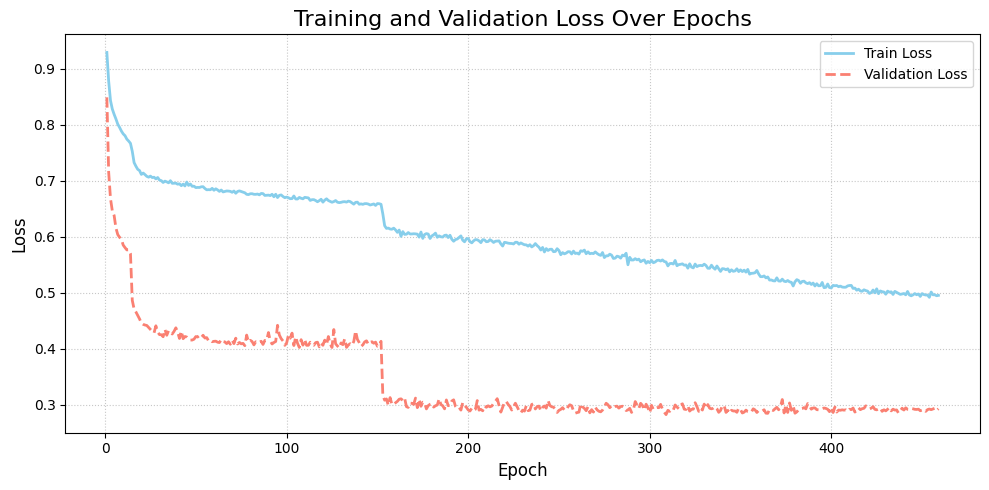

/tmp/ipykernel_2522792/3536557551.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('viridis', num_classes) # Get a colormap for classes


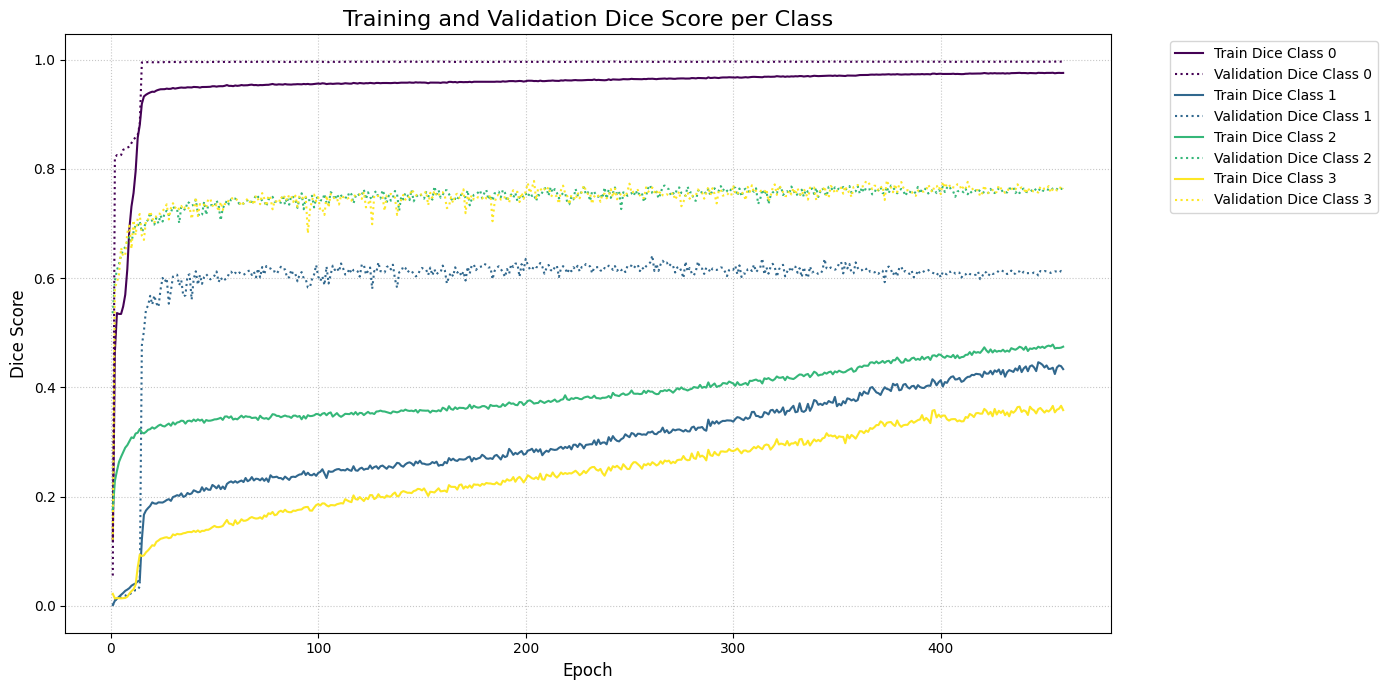

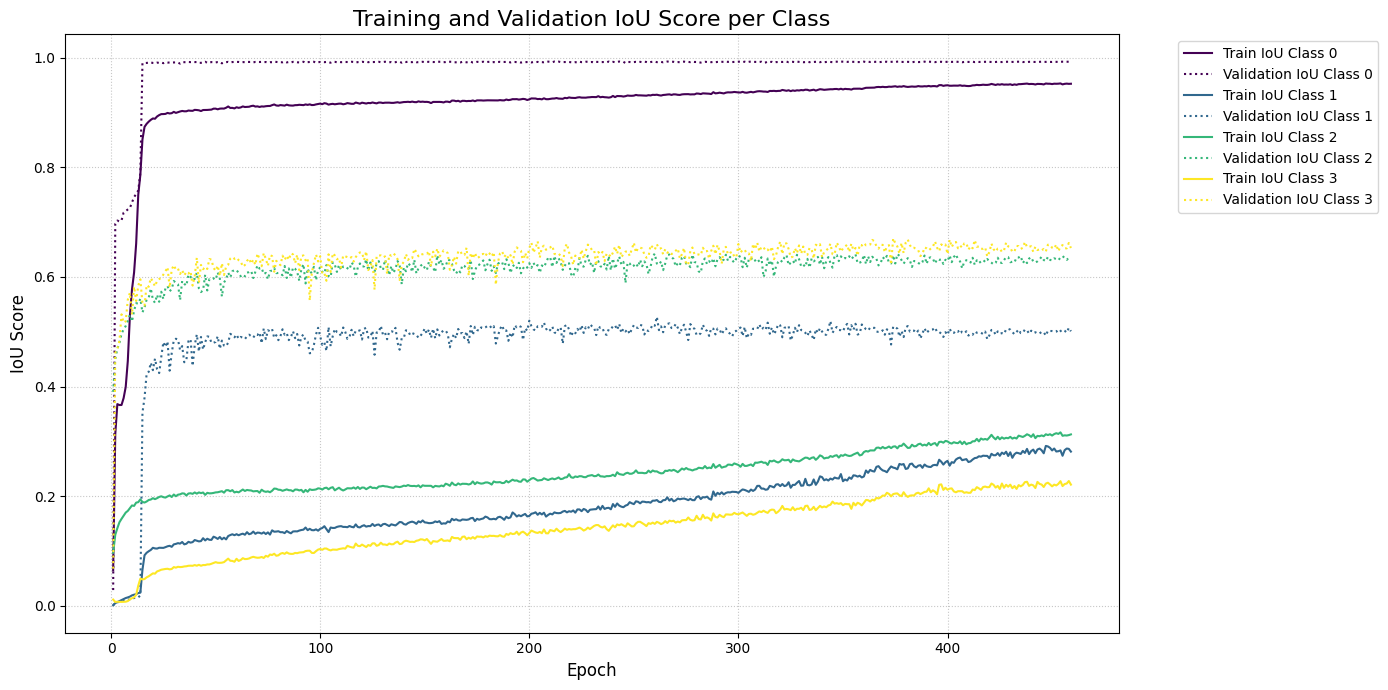


Plotting Complete. Check the generated plots.


In [ ]:


# --- Configuration ---
# Path to the CSV file generated by the training script
METRICS_CSV_PATH = '/home/uiet/BrainTumorModifiedUnet/Output_GlobalNorm/training_and_validation_metrics.csv'
# Number of classes used in your segmentation model
NUM_CLASSES = 4 # 0=background, 1=NCR/NET, 2=ED, 3:ET

# --- Plotting Function ---
def plot_training_curves(metrics_csv_path, num_classes):
    """
    Loads training and validation metrics from a CSV file and plots the curves.

    Args:
        metrics_csv_path (str): Path to the CSV file containing training metrics.
        num_classes (int): Number of segmentation classes.
    """
    if not os.path.exists(metrics_csv_path):
        print(f"Error: Metrics CSV file not found at {metrics_csv_path}. Cannot plot curves.")
        print("Please ensure the training script has been run successfully and saved the metrics CSV.")
        return

    df = pd.read_csv(metrics_csv_path)

    if df.empty:
        print(f"Error: Metrics CSV file at {metrics_csv_path} is empty. Cannot plot curves.")
        return

    epochs = df['Epoch']

    # Plot Loss Curves
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, df['Train_Loss'], label='Train Loss', color='skyblue', linewidth=2)
    plt.plot(epochs, df['Validation_Loss'], label='Validation Loss', color='salmon', linestyle='--', linewidth=2)
    plt.title('Training and Validation Loss Over Epochs', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Plot Dice Score Curves per Class
    plt.figure(figsize=(14, 7))
    colors = plt.cm.get_cmap('viridis', num_classes) # Get a colormap for classes
    
    for i in range(num_classes):
        plt.plot(epochs, df[f'Train_Dice_Class_{i}'], label=f'Train Dice Class {i}', color=colors(i), linewidth=1.5)
        plt.plot(epochs, df[f'Validation_Dice_Class_{i}'], label=f'Validation Dice Class {i}', color=colors(i), linestyle=':', linewidth=1.5)
    
    plt.title('Training and Validation Dice Score per Class', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Dice Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Plot IoU Score Curves per Class
    plt.figure(figsize=(14, 7))
    for i in range(num_classes):
        plt.plot(epochs, df[f'Train_IoU_Class_{i}'], label=f'Train IoU Class {i}', color=colors(i), linewidth=1.5)
        plt.plot(epochs, df[f'Validation_IoU_Class_{i}'], label=f'Validation IoU Class {i}', color=colors(i), linestyle=':', linewidth=1.5)
    
    plt.title('Training and Validation IoU Score per Class', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('IoU Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()


# --- Main Execution Block for Plotting Script ---
if __name__ == "__main__":
    print("Starting BraTS 2020 Training Metrics Plotting Script...")
    
    # Call the plotting function
    plot_training_curves(METRICS_CSV_PATH, NUM_CLASSES)

    print("\nPlotting Complete. Check the generated plots.")


# Prediction

Starting BraTS 2020 2D Segmentation Prediction and Evaluation Script...

Loaded test metadata from: /home/uiet/BrainTumorModifiedUnet/Metadata/brats2020_test_metadata.csv
Number of patients in test set: 37
Using device for prediction: cuda


/tmp/ipykernel_1371134/3572159317.py:62: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))



Loaded model from: /home/uiet/BrainTumorModifiedUnet/Output_GlobalNorm/brats_2d_segmentation_best_model.pth
Pre-loading and processing all valid slices for 37 patients...


Loading Patients: 100%|██████████| 37/37 [00:14<00:00,  2.59it/s]


Finished pre-loading. Total valid 2D slices cached: 1736

Class distribution across valid slices (each count means at least one pixel of that class is present in the slice):
  Class 0: 1736 slices
  Class 1: 1261 slices
  Class 2: 1733 slices
  Class 3: 1301 slices
Test Dataset size (total valid 2D slices): 1736
Test DataLoader created with batch_size=1, num_workers=20

Starting prediction and evaluation on test set...


Predicting on Test Set:   0%|          | 0/1736 [00:00<?, ?it/s]/tmp/ipykernel_1371134/3572159317.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Predicting on Test Set: 100%|██████████| 1736/1736 [00:24<00:00, 71.57it/s]



--- Test Set Performance on BraTS Evaluation Classes ---
Average Dice Score for Whole Tumor (WT): 0.8941
Average IoU Score for Whole Tumor (WT):  0.8187
Average Precision for Whole Tumor (WT): 0.8834
Average Dice Score for Tumor Core (TC): 0.7569
Average IoU Score for Tumor Core (TC):  0.6900
Average Precision for Tumor Core (TC): 0.8502
Average Dice Score for Enhancing Tumor (ET): 0.7864
Average IoU Score for Enhancing Tumor (ET):  0.7106
Average Precision for Enhancing Tumor (ET): 0.8296

Overall Average (WT, TC, ET) Dice Score: 0.8125
Overall Average (WT, TC, ET) IoU Score:  0.7397
Overall Average (WT, TC, ET) Precision Score:  0.8544

Visualizing 20 random test samples...


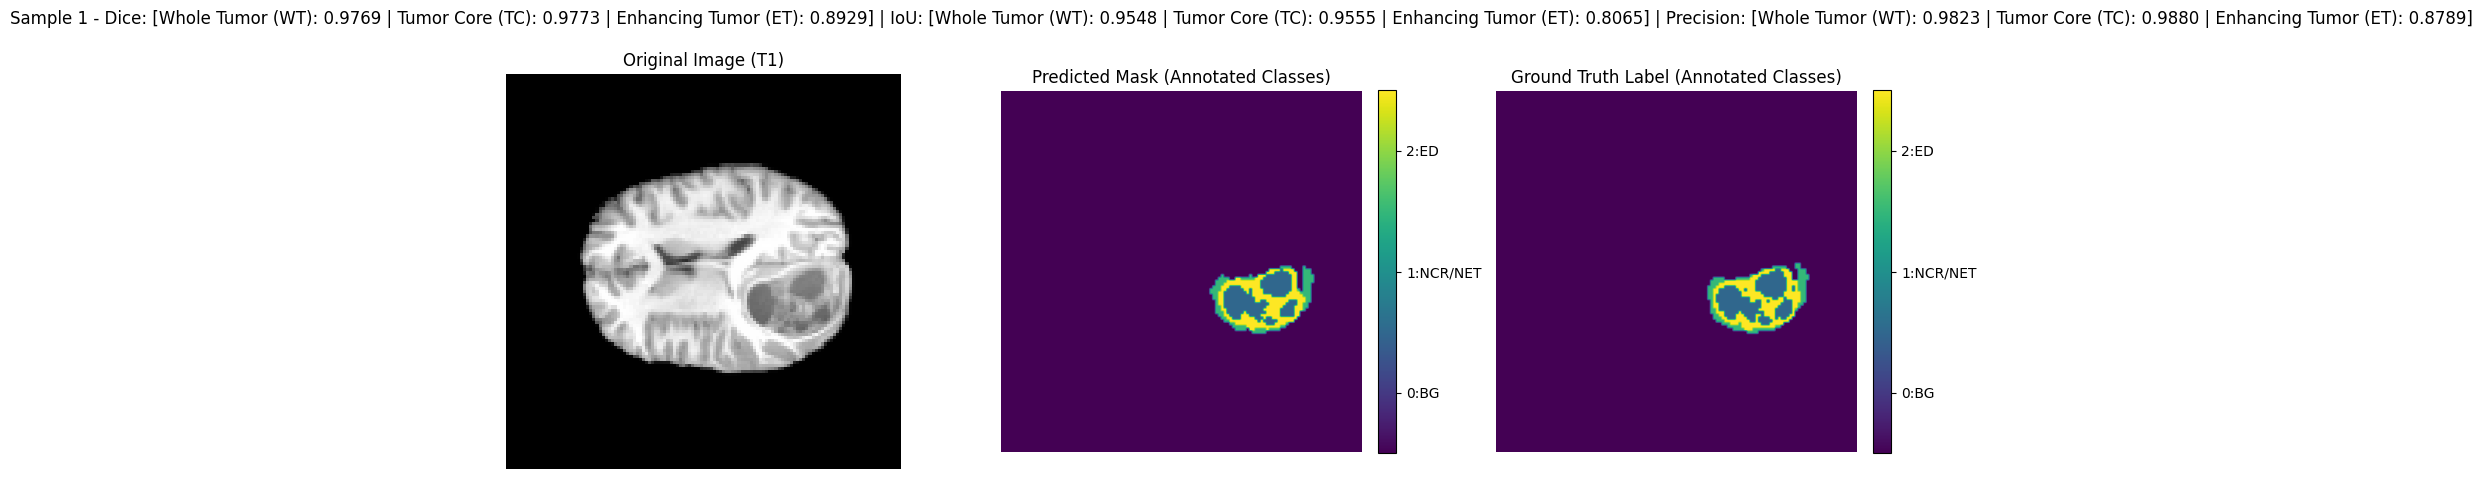

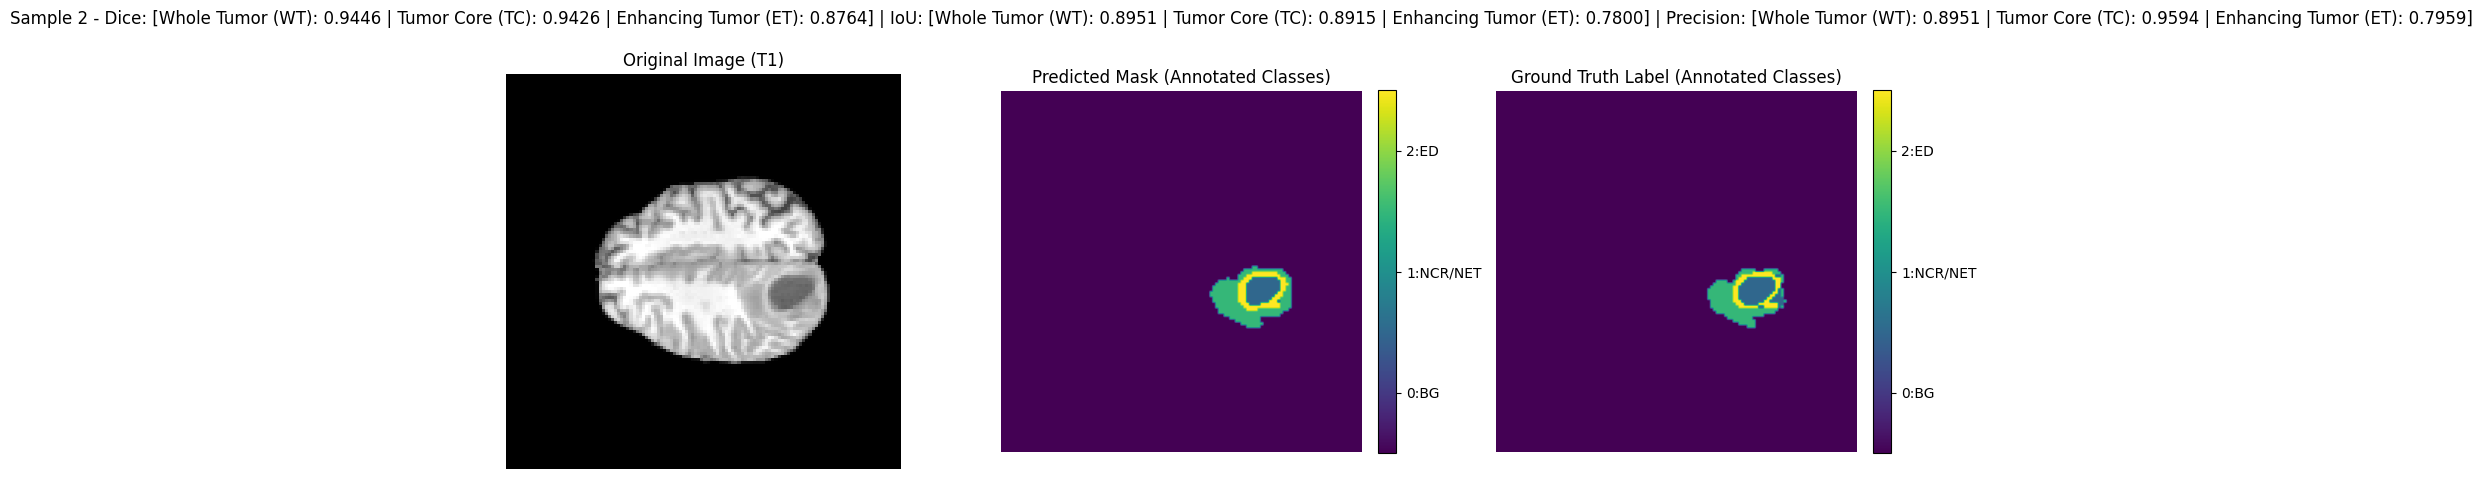

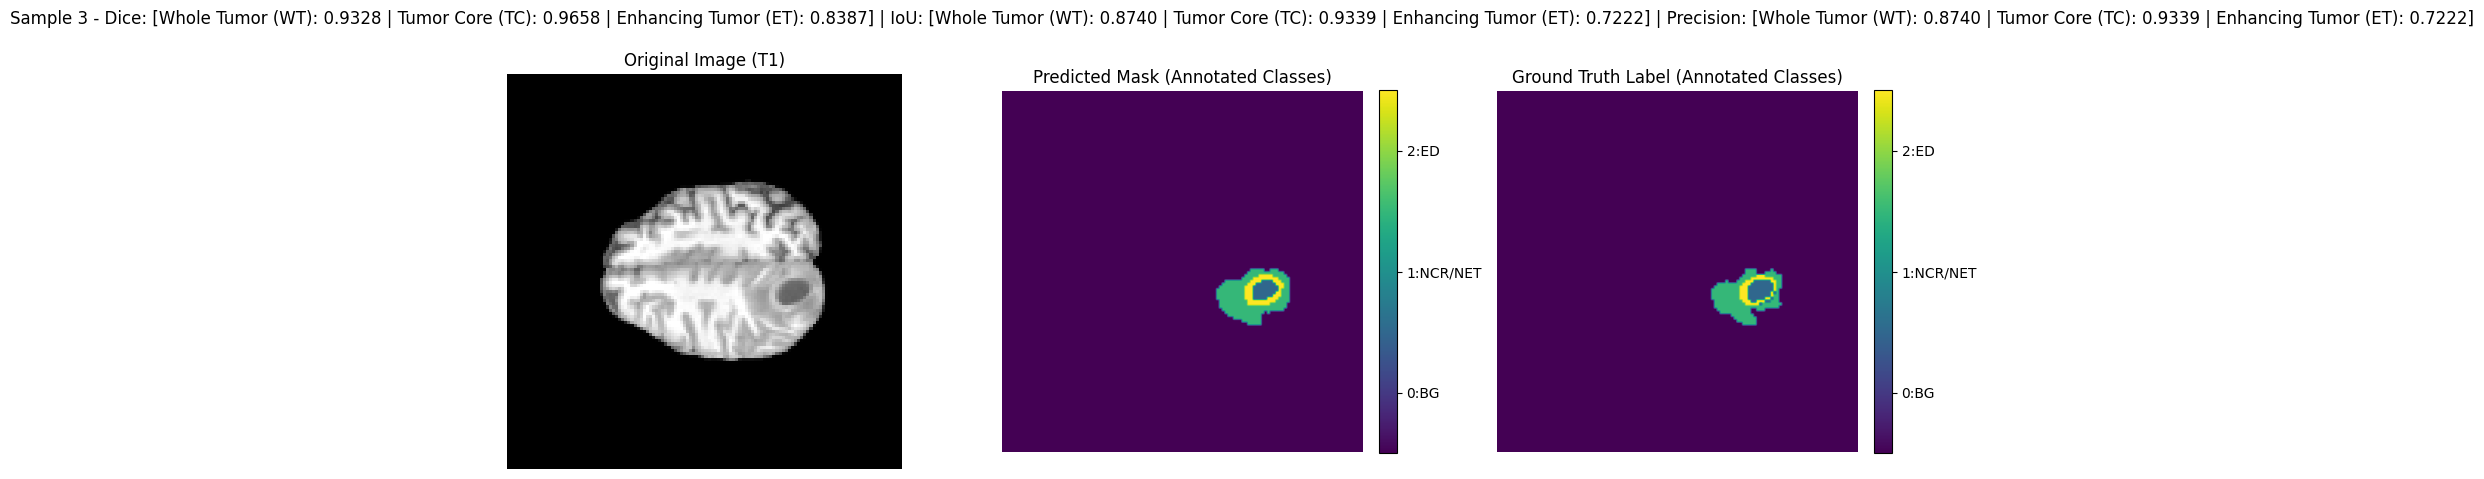

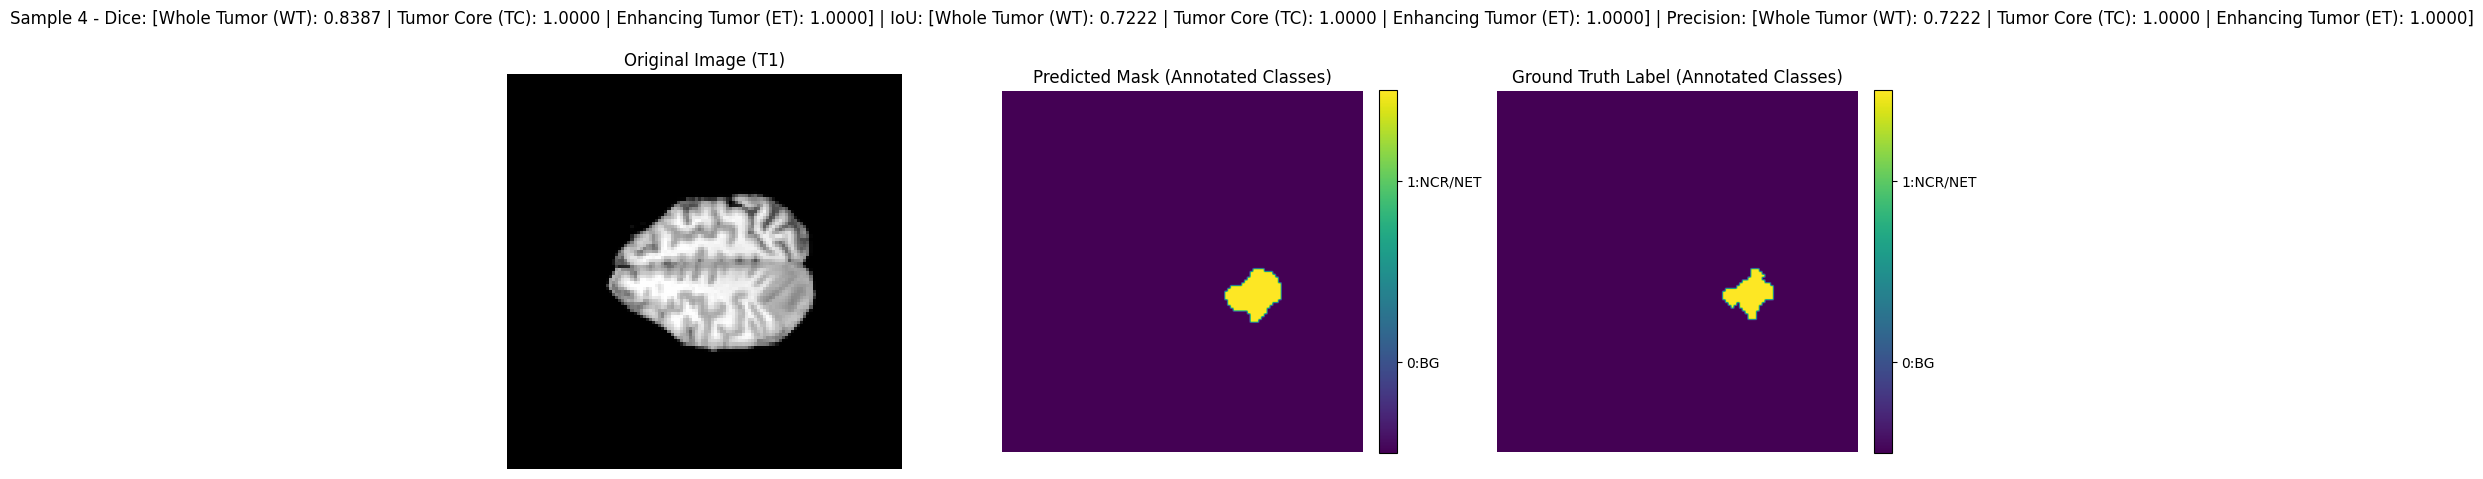

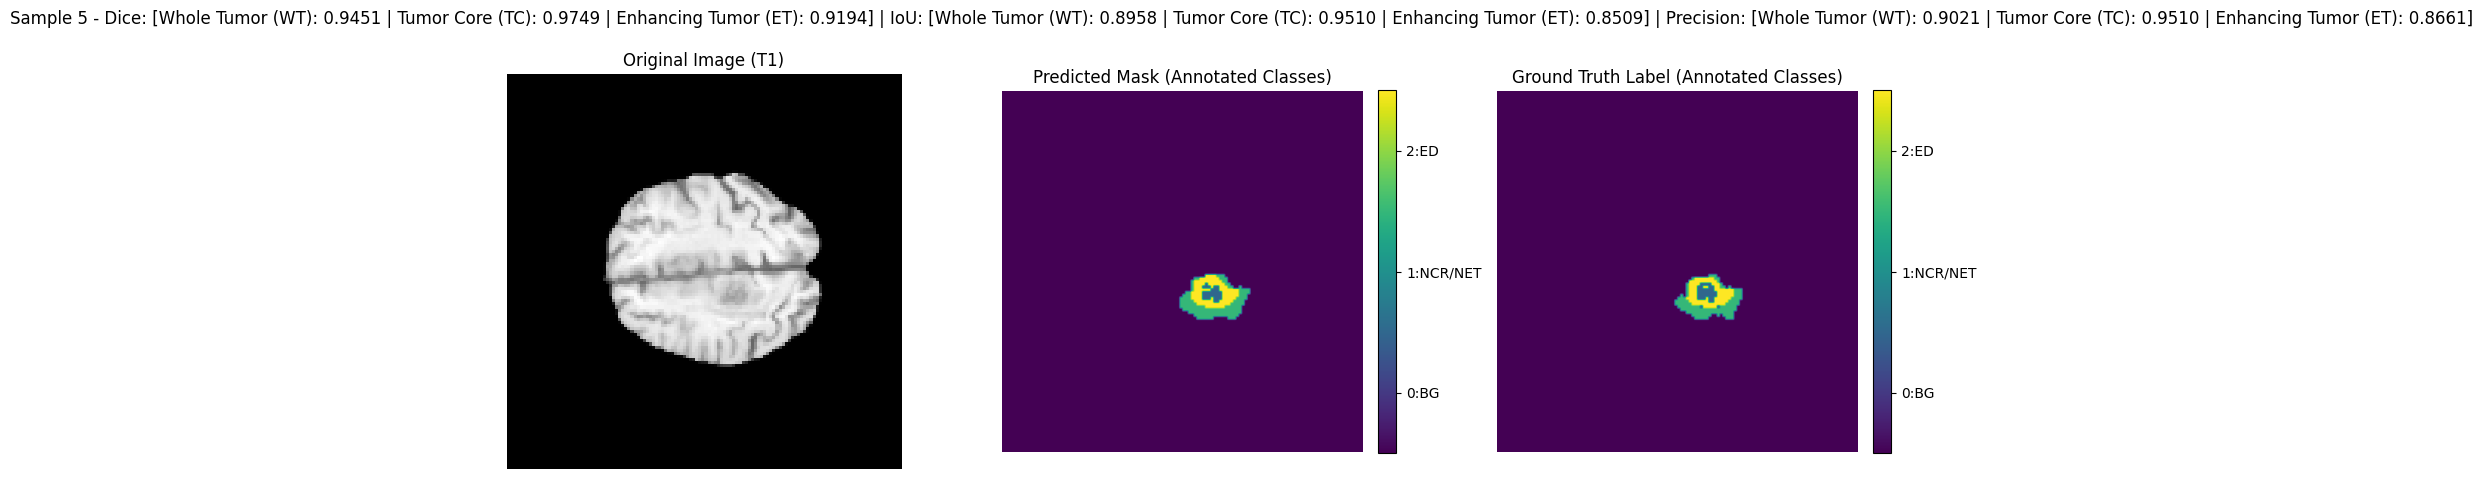

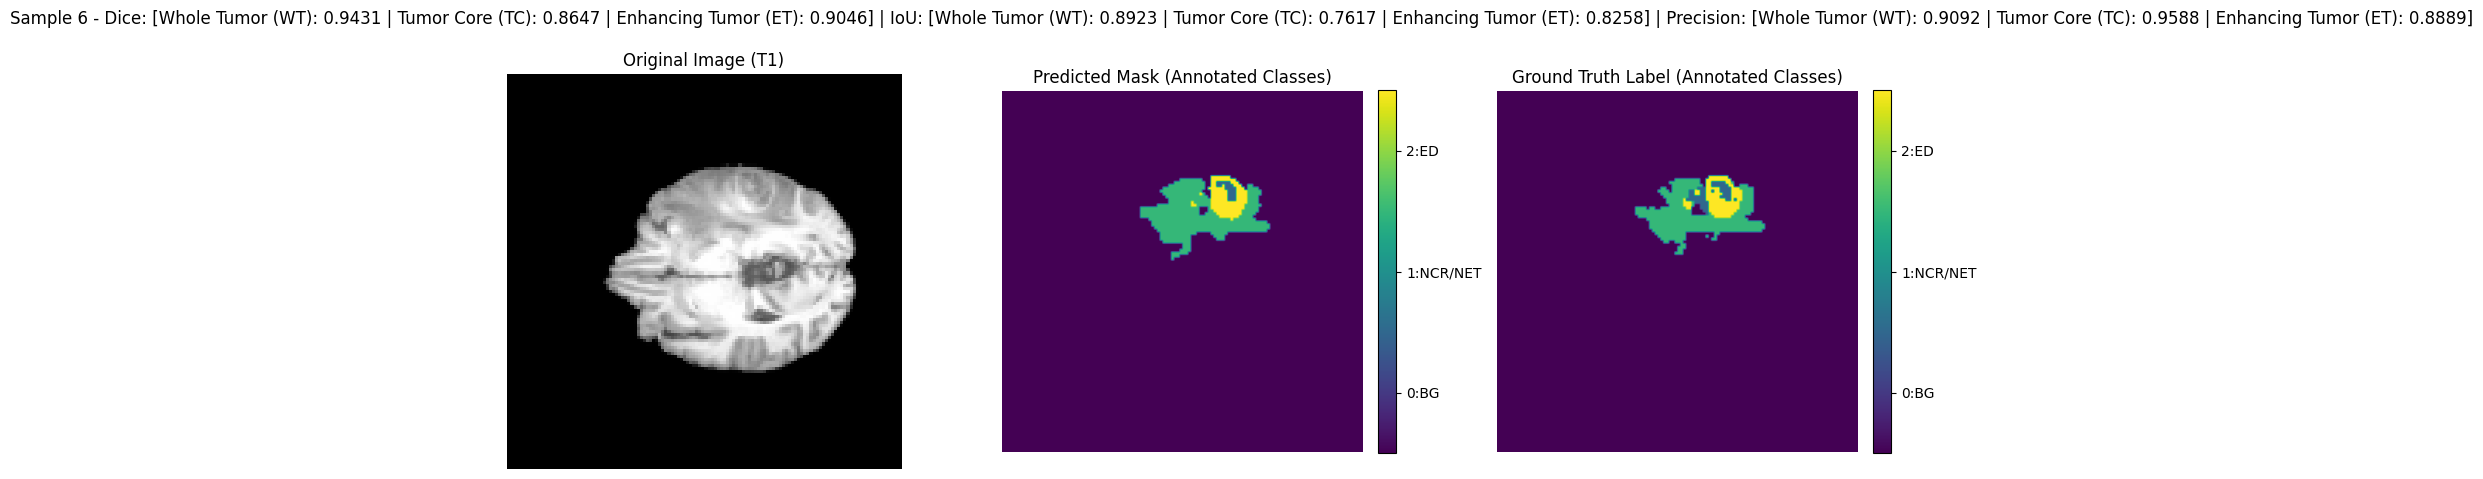

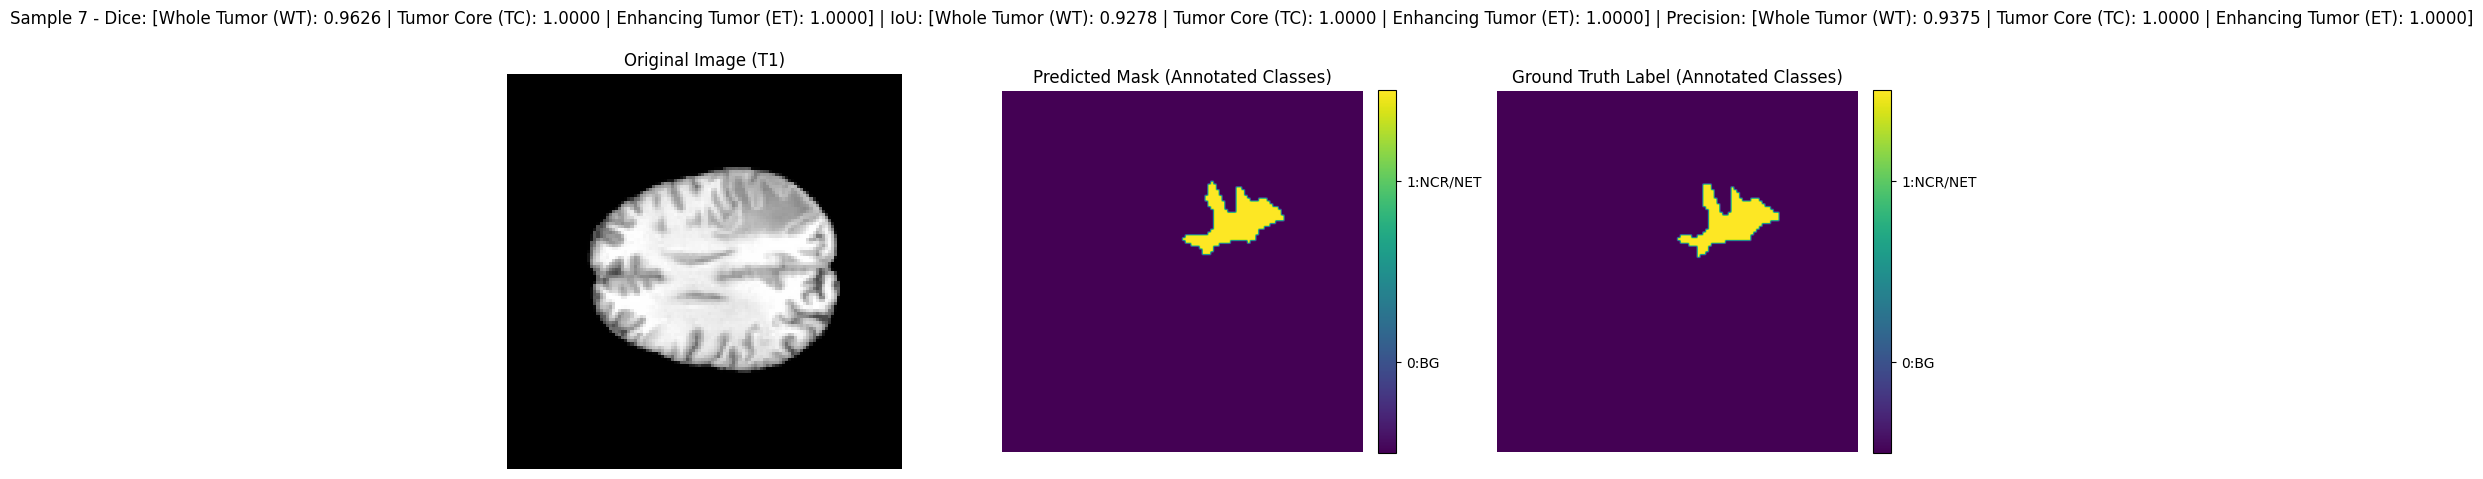

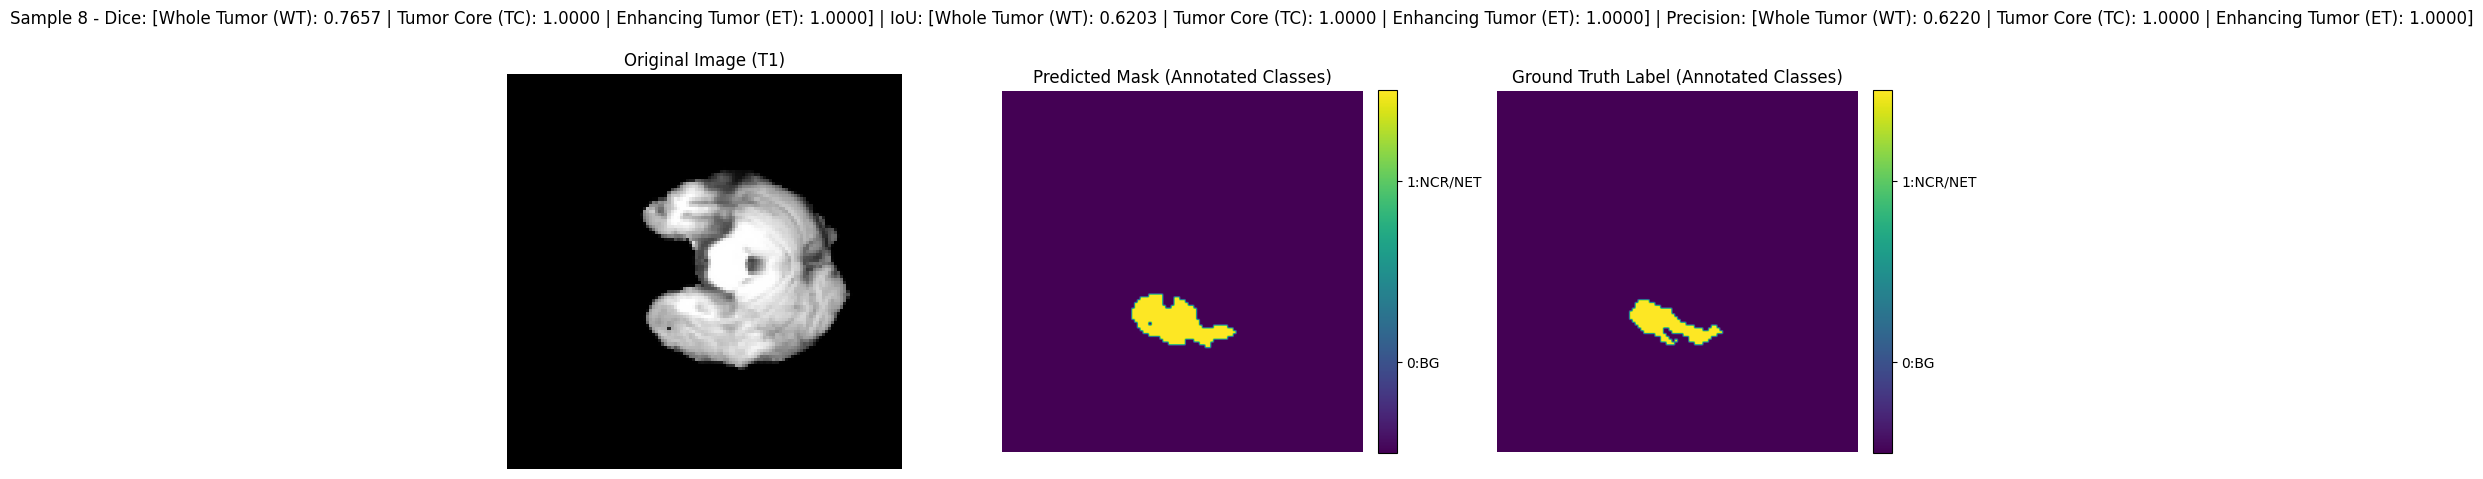

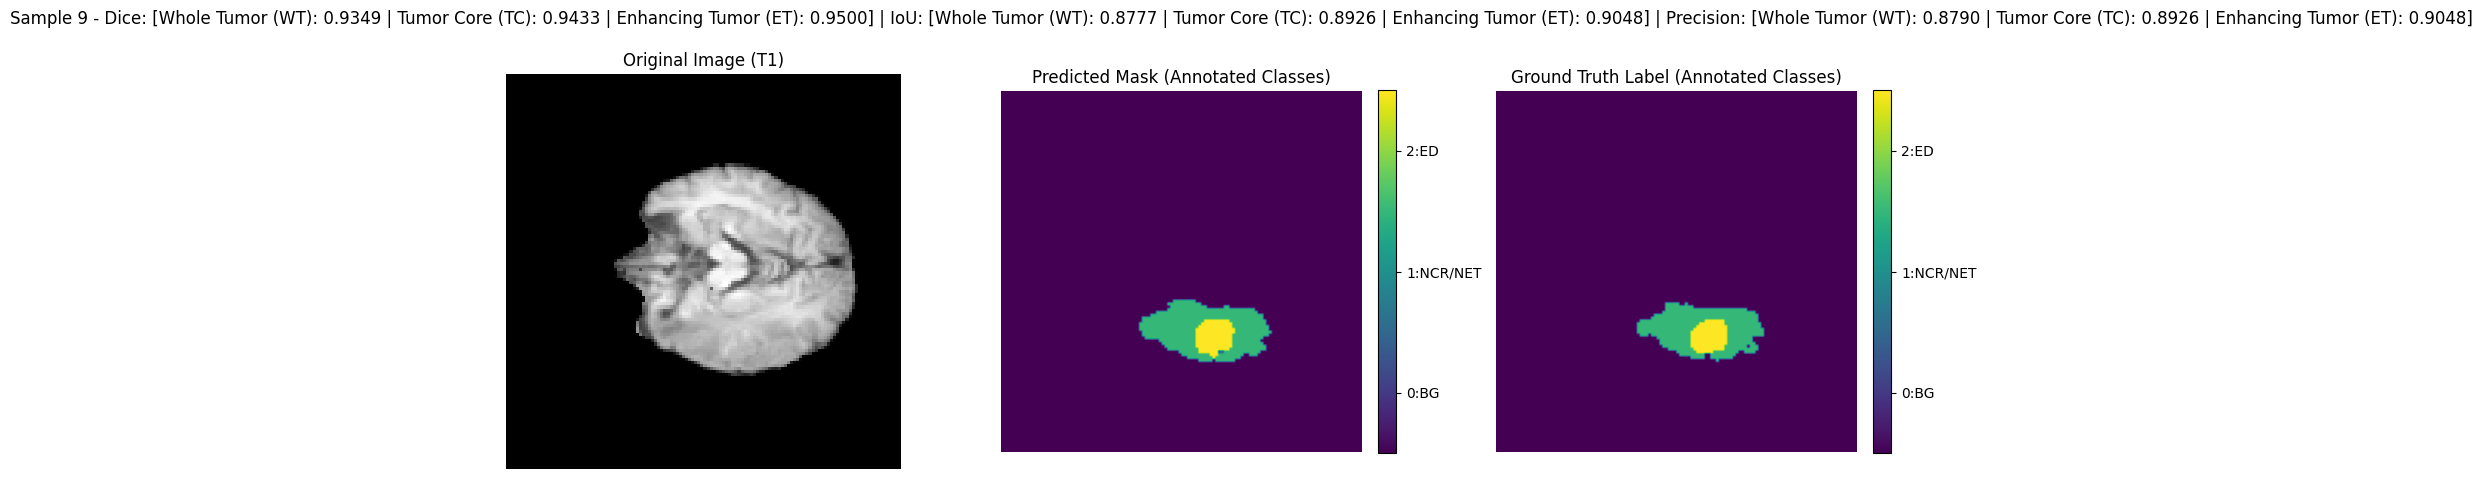

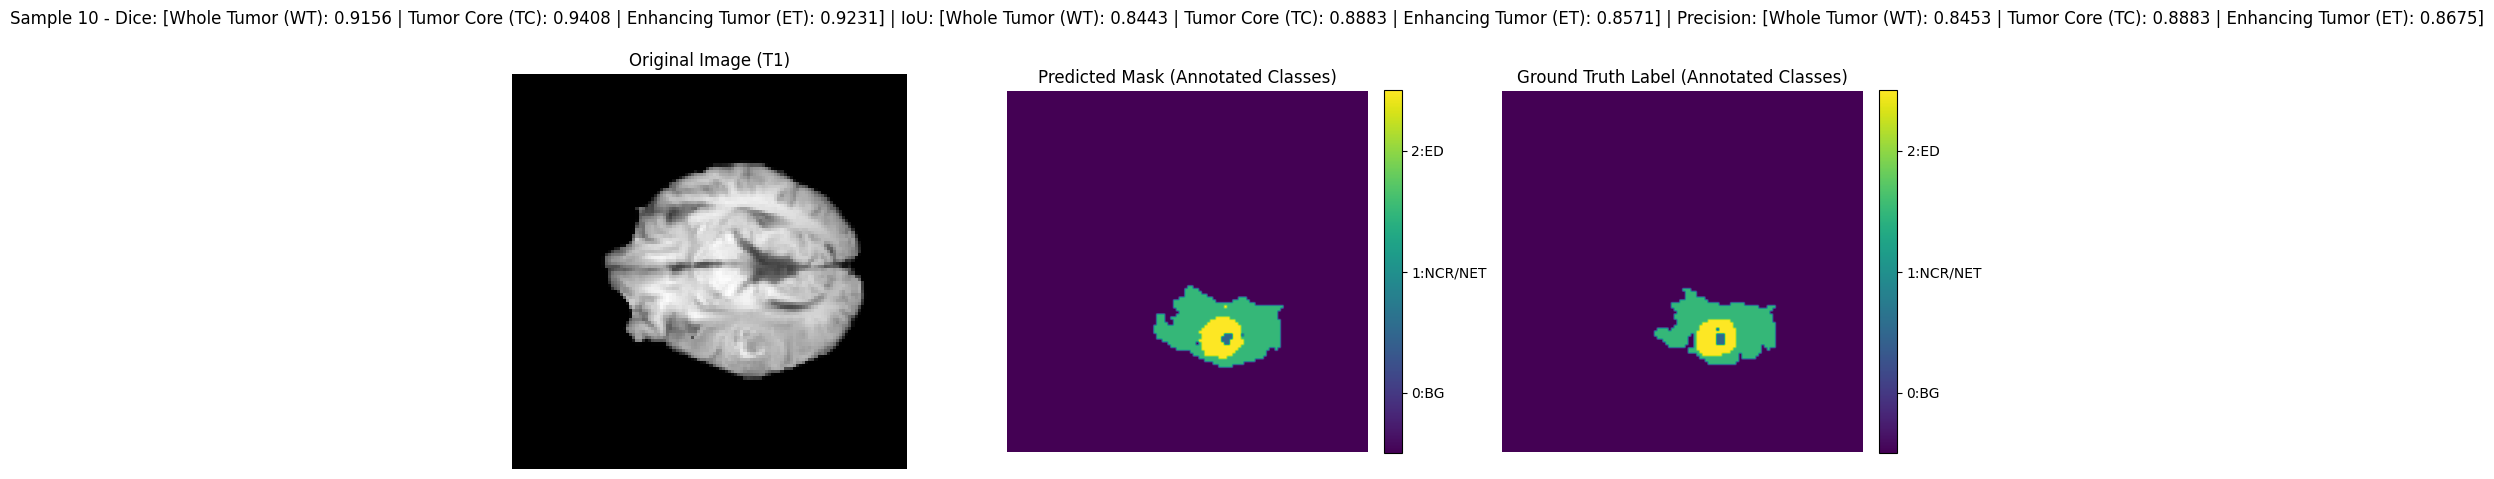

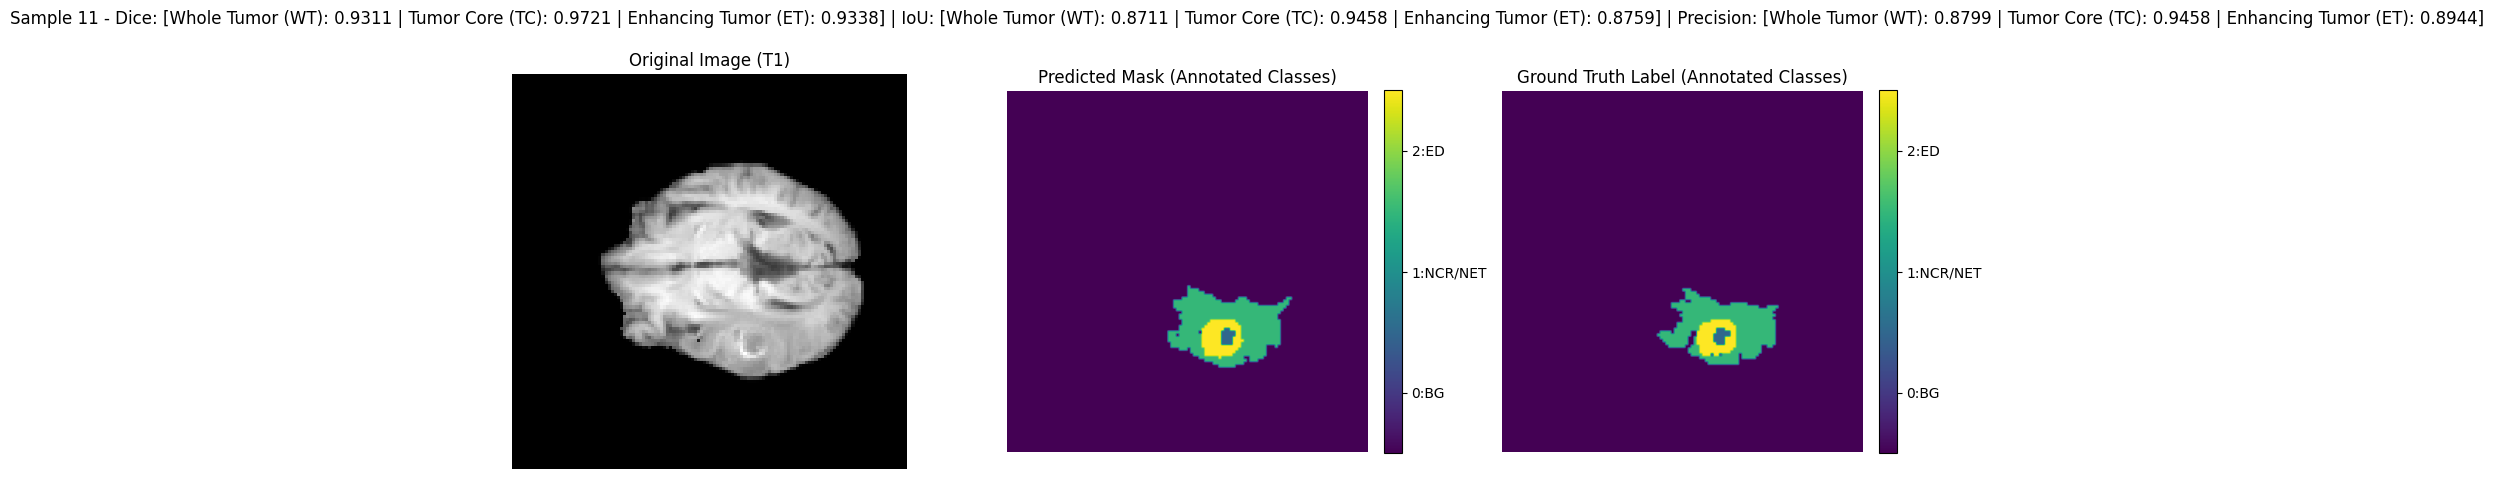

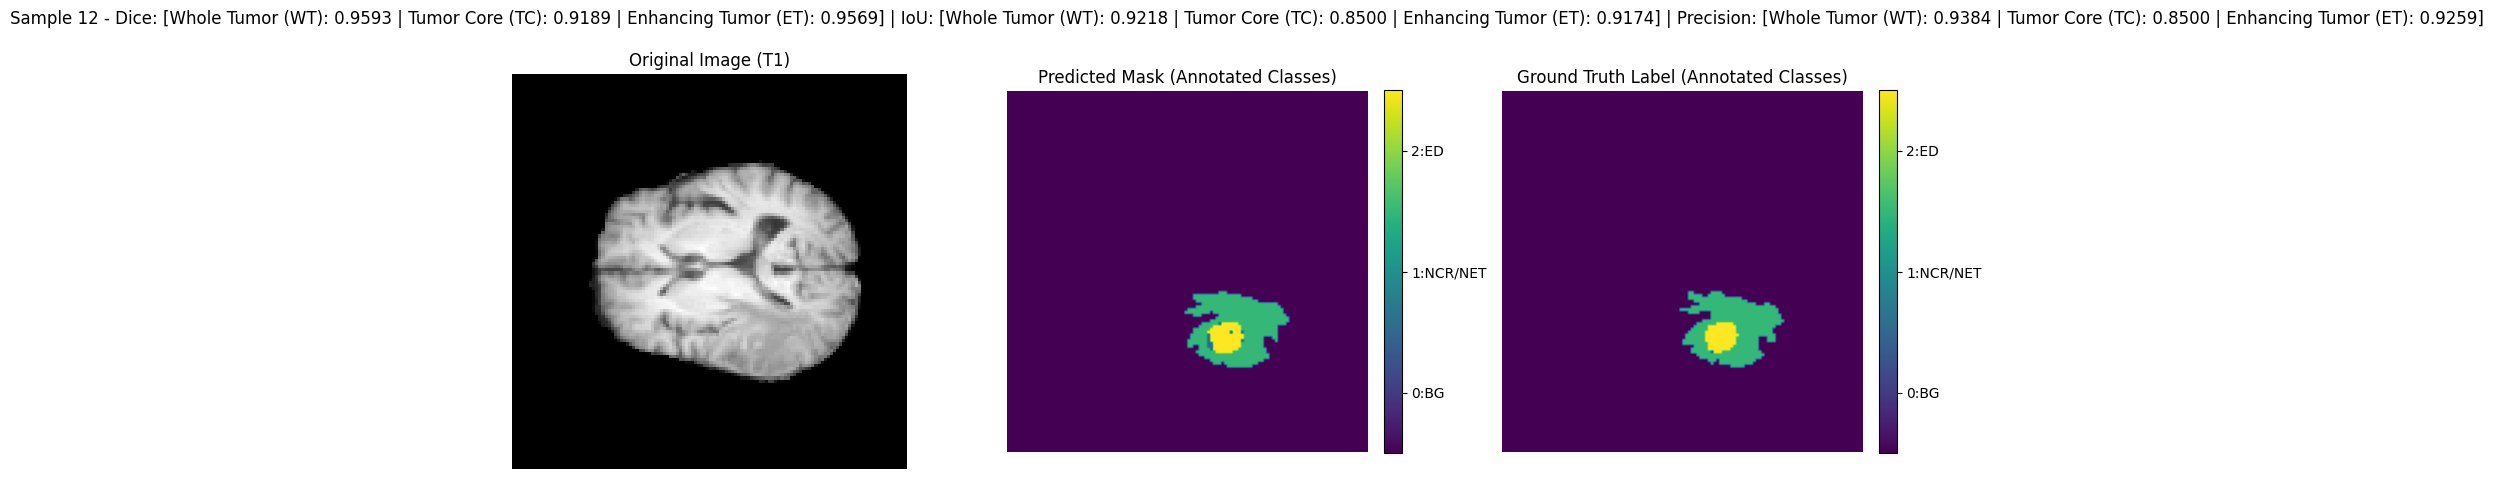

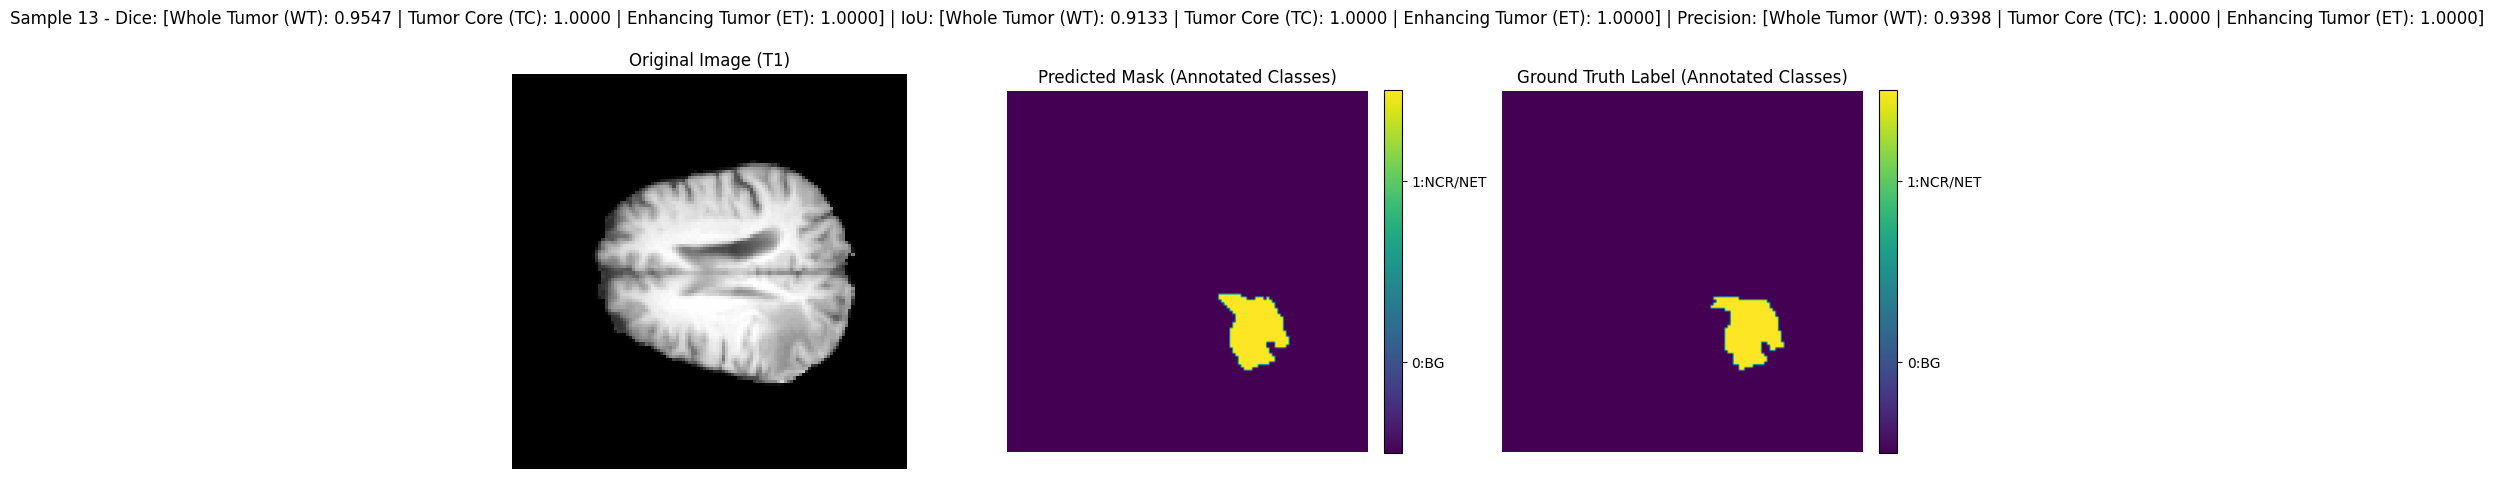

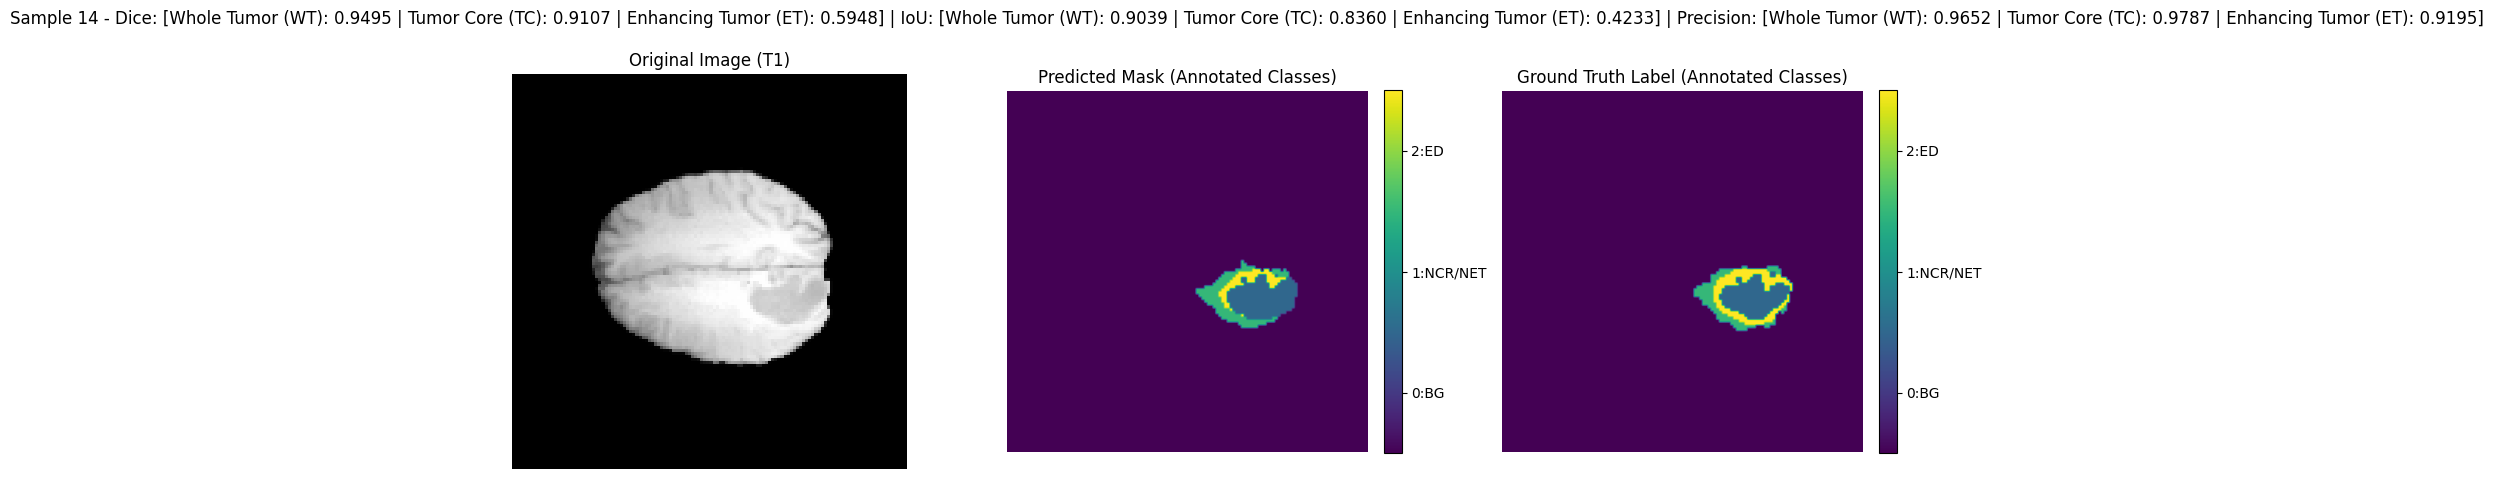

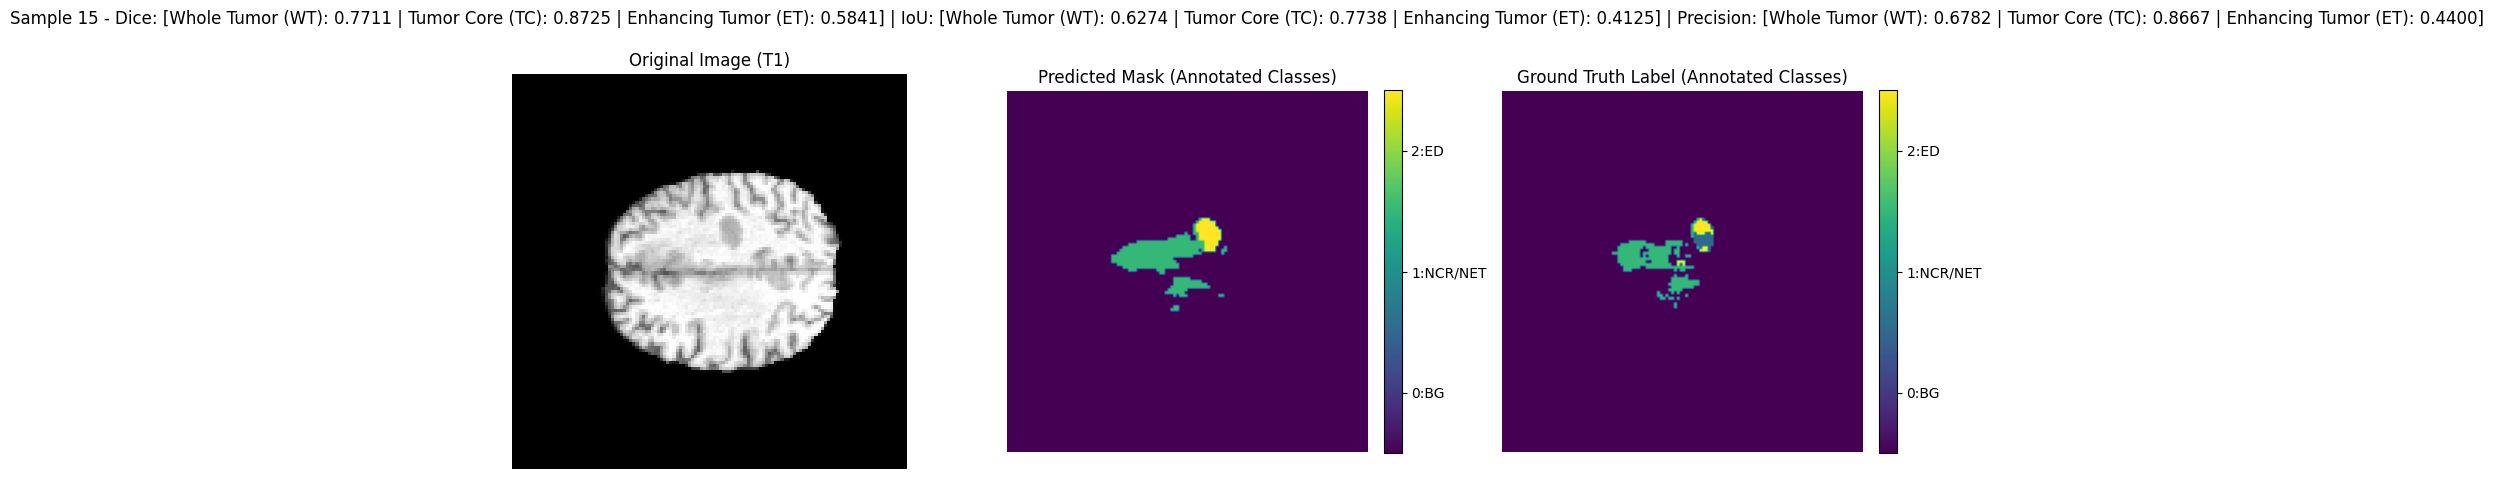

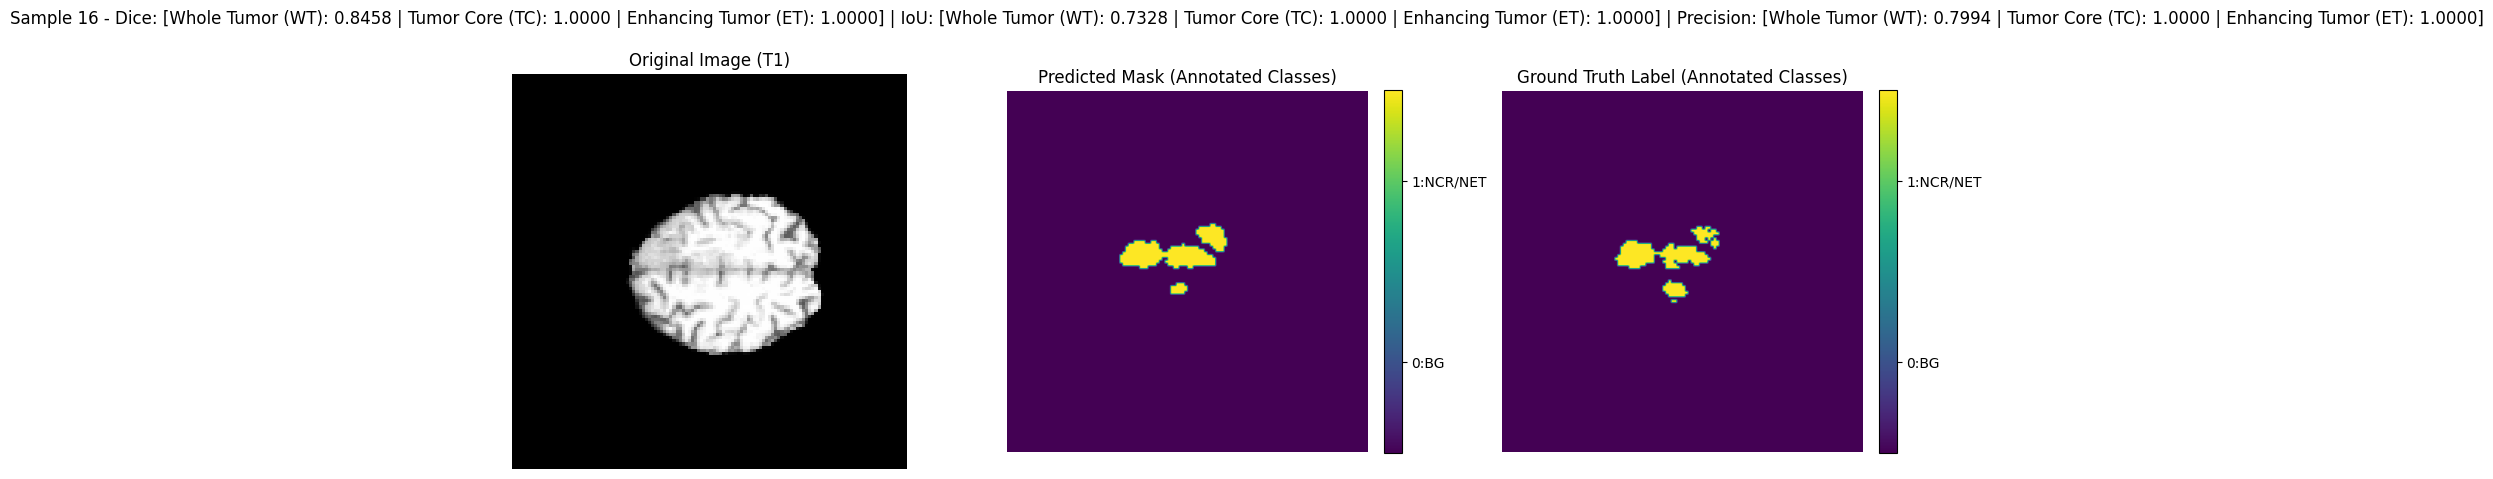

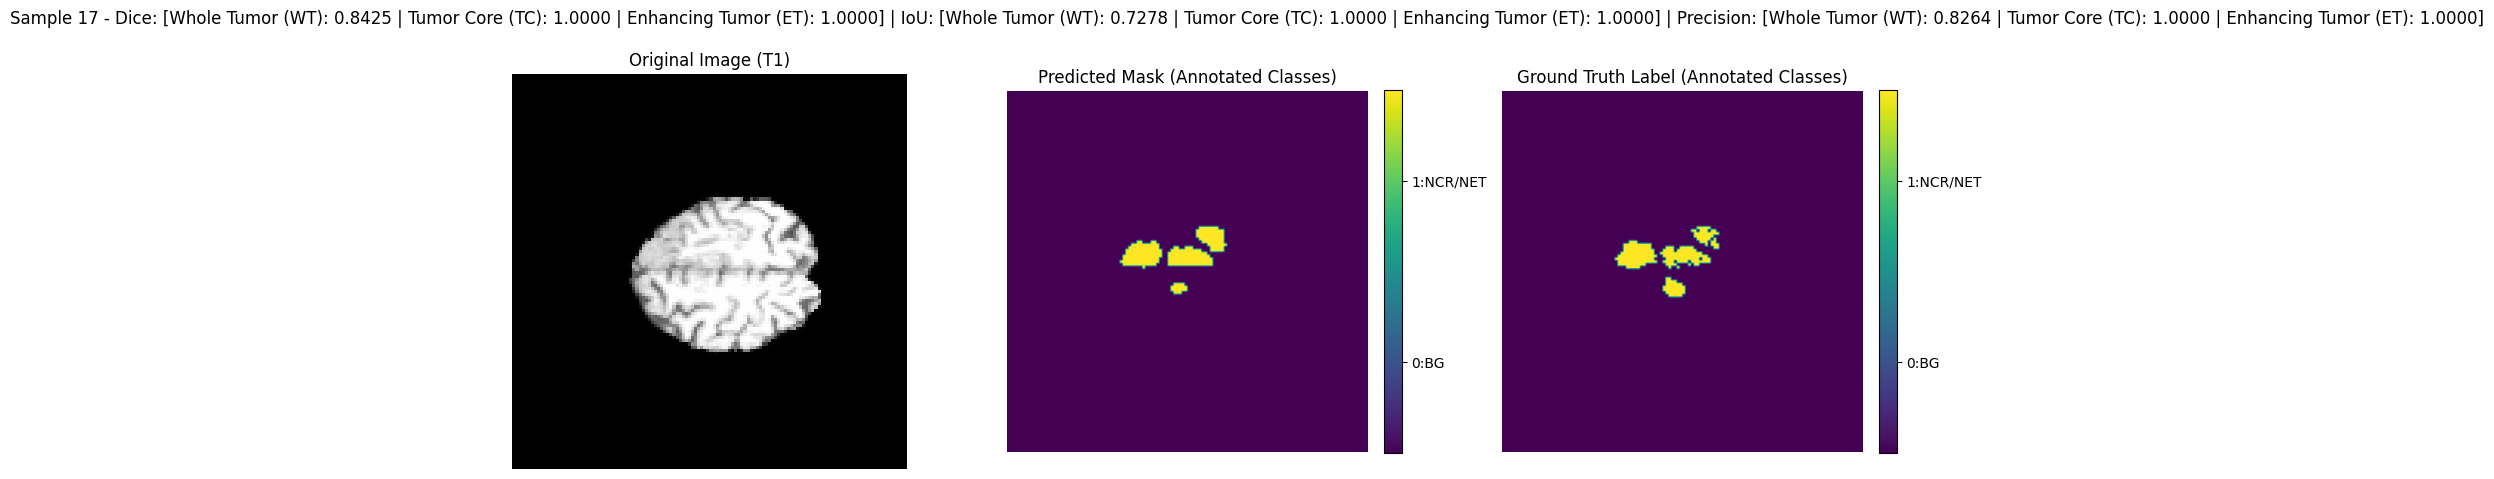

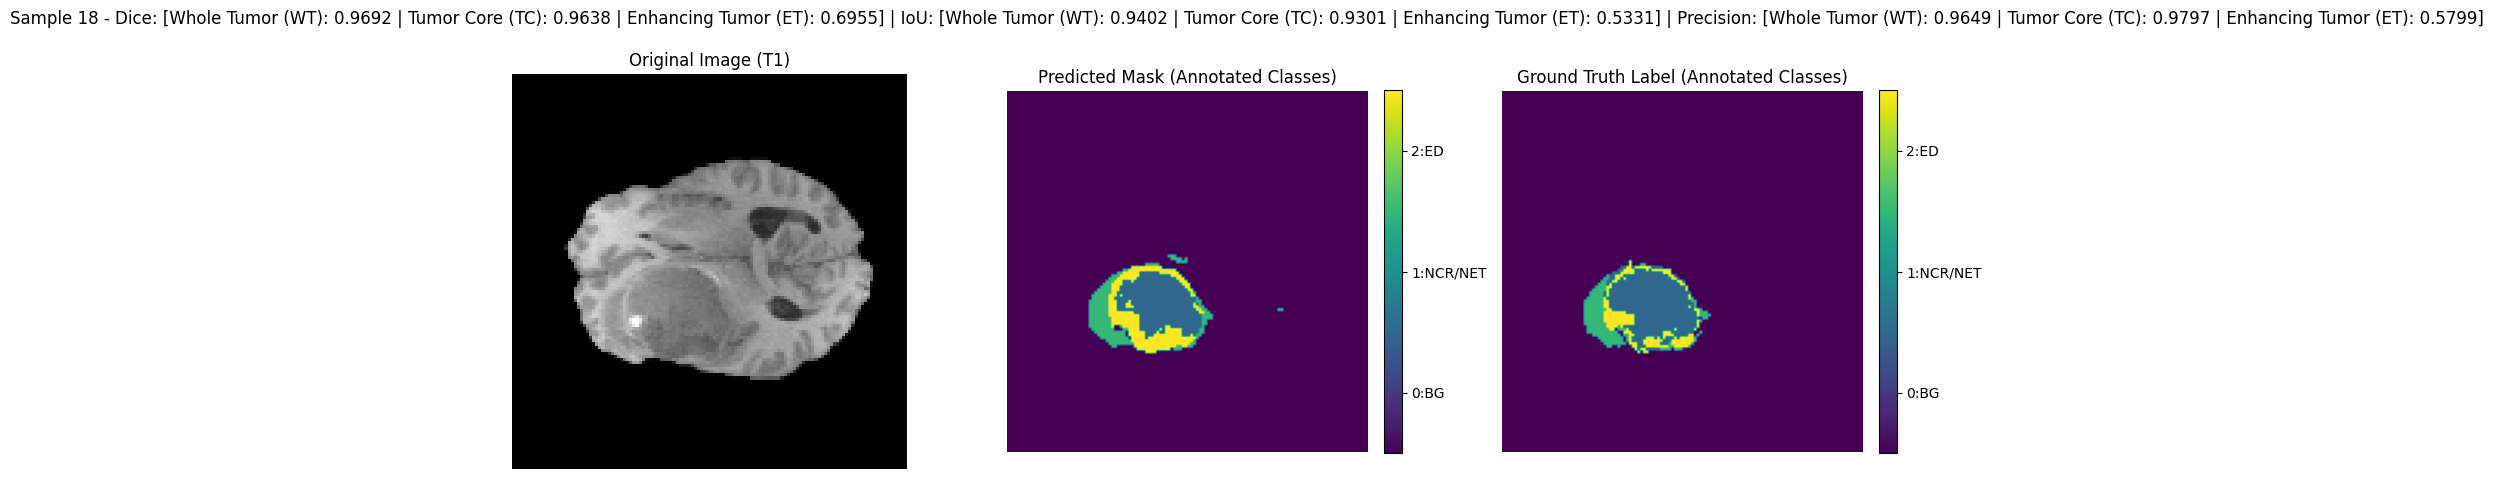

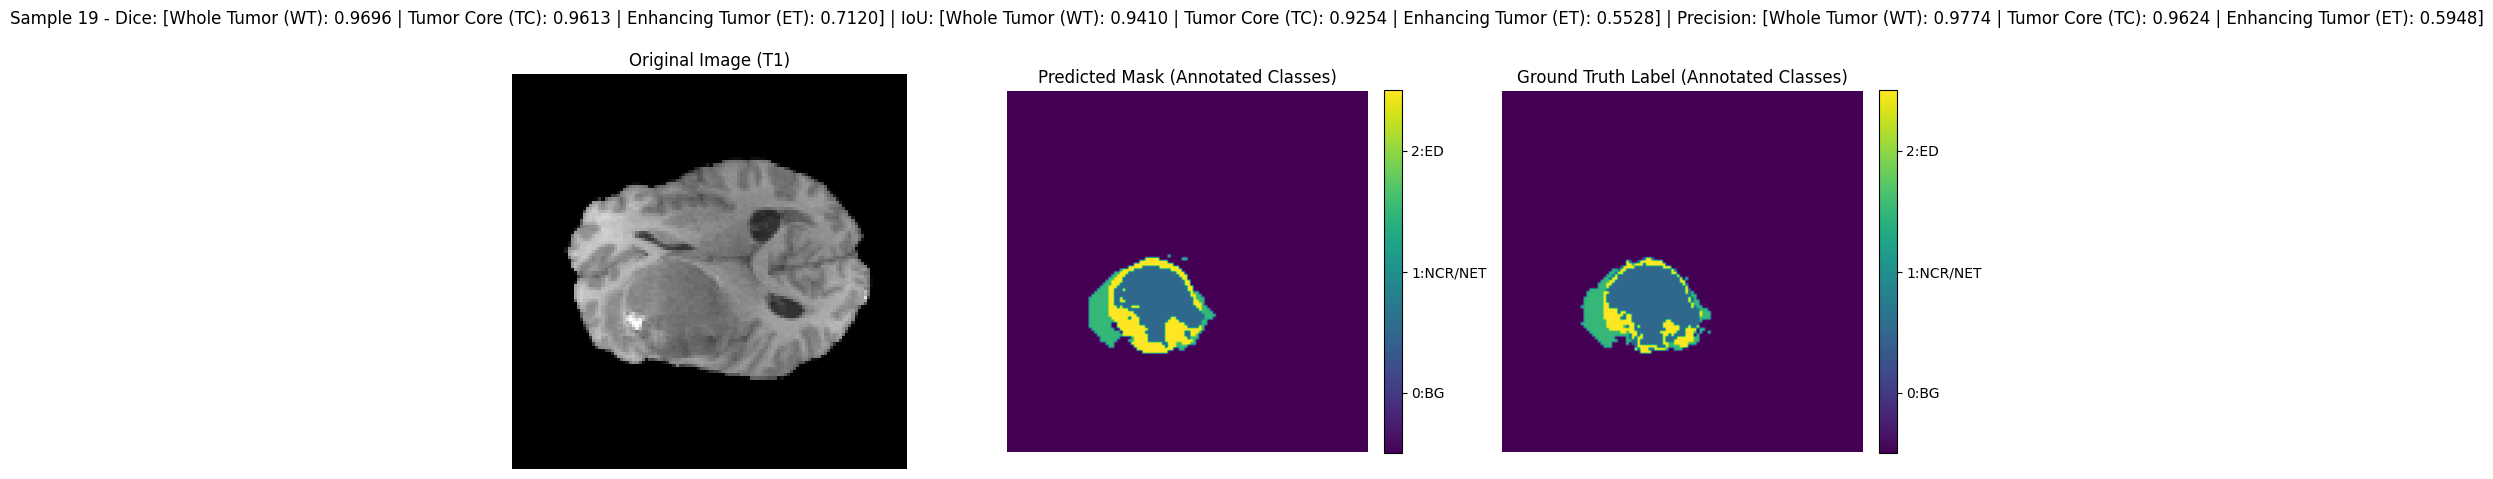

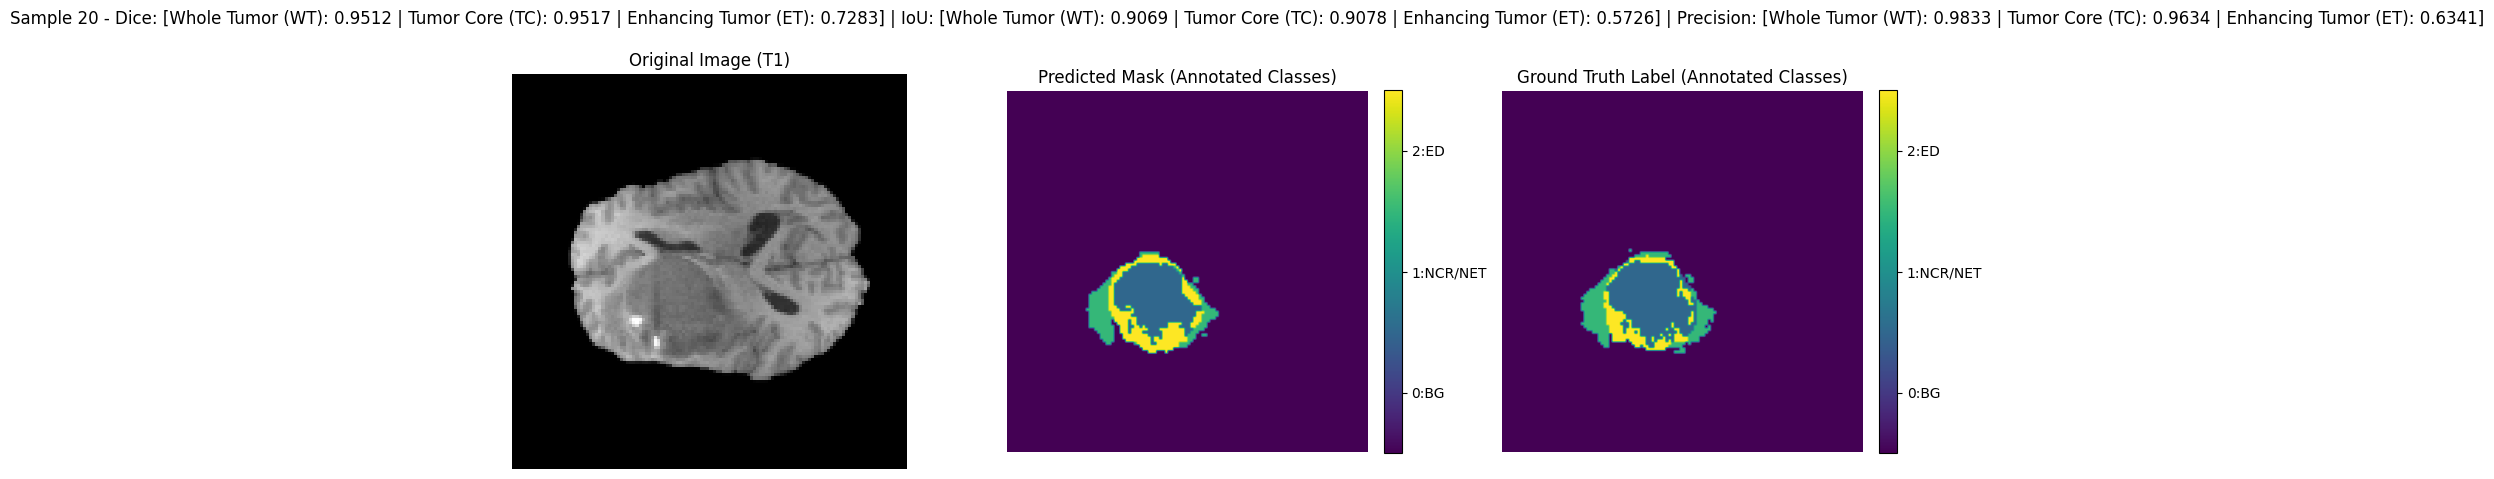


Prediction and Evaluation Script Finished.


In [15]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random
from skimage.transform import resize as skimage_resize # Added for clarity, as it's used by imported Dataset

# For Automatic Mixed Precision (AMP) - useful for consistent inference if trained with AMP
from torch.cuda.amp import autocast # Corrected import for AMP

# --- Configuration (Must match training and preprocessing configurations) ---
IMAGE_SIZE = (128, 128)
SLICE_AXIS = 'axial'
MIN_PIXEL_THRESHOLD = 0.01
NUM_CLASSES = 4  # Including background, NCR/NET, ED, and ET
INPUT_CHANNELS = 4  # Assuming T1, T1ce, T2, FLAIR
OUTPUT_CHANNELS = NUM_CLASSES

# --- BraTS Evaluation Class Definitions ---
# Evaluation Classes (ECs): WT, TC, ET
EC_NAMES = ["Whole Tumor (WT)", "Tumor Core (TC)", "Enhancing Tumor (ET)"]
NUM_EVAL_CLASSES = 3

# --- Utility Metric Functions (Binary Dice/IoU) ---
def calculate_binary_dice_score(pred, target, smooth=1e-8):
    """Calculates Dice score for two binary tensors."""
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

def calculate_binary_iou_score(pred, target, smooth=1e-8):
    """Calculates IoU score for two binary tensors."""
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou

def calculate_precision_score(pred, target, smooth=1e-8):
    """Calculates precision score for binary tensors."""
    true_positives = (pred * target).sum()
    false_positives = (pred * (1 - target)).sum()
    precision = (true_positives + smooth) / (true_positives + false_positives + smooth)
    return precision

# --- Main Prediction and Evaluation Function ---
def predict_and_evaluate(model_path, test_df, num_classes, device, num_samples_to_visualize=3):
    """
    Loads a trained model, performs predictions on the test set, evaluates performance
    based on **BraTS Evaluation Classes (WT, TC, ET)**, and visualizes example predictions.
    """
    model = ResNeXtTransformerASPP_CNN(
        in_channels=INPUT_CHANNELS,
        num_output_channels=OUTPUT_CHANNELS,
        dropout_encoder_rate=0.2
    )
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    print(f"\nLoaded model from: {model_path}")

    test_dataset = BraTS2020_2DSegmentationDataset(
        dataframe=test_df,
        augment=False,
        slice_axis=SLICE_AXIS,
        min_pixel_threshold=MIN_PIXEL_THRESHOLD,
        image_size=IMAGE_SIZE
    )
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)
    print(f"Test Dataset size (total valid 2D slices): {len(test_dataset)}")
    print(f"Test DataLoader created with batch_size=1, num_workers={os.cpu_count()}")

    # Initialize accumulation for the 3 Evaluation Classes (WT, TC, ET)
    total_dice_scores_ec = torch.zeros(NUM_EVAL_CLASSES, device=device)
    total_iou_scores_ec = torch.zeros(NUM_EVAL_CLASSES, device=device)
    total_precision_scores_ec = torch.zeros(NUM_EVAL_CLASSES, device=device)
    num_test_samples = 0
    visualization_samples = []

    all_dataset_indices = list(range(len(test_dataset)))
    random.shuffle(all_dataset_indices)
    
    # Select indices for visualization. Since DataLoader is not shuffled, indices i will work.
    selected_visual_indices = []
    
    # We must iterate over a random set of indices to get diverse samples
    print("\nStarting prediction and evaluation on test set...")
    with torch.no_grad():
        for i, (images, masks) in enumerate(tqdm(test_loader, desc="Predicting on Test Set")):
            images = images.to(device)
            masks = masks.to(device)

            with autocast():
                outputs = model(images)

            # Get the predicted label map (B=1, H, W)
            predicted_masks = torch.argmax(outputs, dim=1)
            
            # --- BraTS Evaluation Class Mapping ---
            # 1. Whole Tumor (WT): ACs 1, 2, 3
            pred_wt = (predicted_masks > 0).float()
            mask_wt = (masks > 0).float()
            
            # 2. Tumor Core (TC): ACs 1, 3
            pred_tc = ((predicted_masks == 1) | (predicted_masks == 3)).float()
            mask_tc = ((masks == 1) | (masks == 3)).float()

            # 3. Enhancing Tumor (ET): AC 3
            pred_et = (predicted_masks == 3).float()
            mask_et = (masks == 3).float()
            
            # Group predictions and masks for iteration
            pred_list = [pred_wt, pred_tc, pred_et]
            mask_list = [mask_wt, mask_tc, mask_et]

            # Accumulate Dice, IoU, and Precision for the 3 ECs
            current_dice_scores = []
            current_iou_scores = []
            current_precision_scores = []
            
            for j in range(NUM_EVAL_CLASSES):
                dice = calculate_binary_dice_score(pred_list[j], mask_list[j])
                iou = calculate_binary_iou_score(pred_list[j], mask_list[j])
                precision = calculate_precision_score(pred_list[j], mask_list[j])

                current_dice_scores.append(dice)
                current_iou_scores.append(iou)
                current_precision_scores.append(precision)

            total_dice_scores_ec += torch.tensor(current_dice_scores, device=device)
            total_iou_scores_ec += torch.tensor(current_iou_scores, device=device)
            total_precision_scores_ec += torch.tensor(current_precision_scores, device=device)
            num_test_samples += 1

            # --- Visualization Sample Collection ---
            # Randomly collect samples that have non-empty ground truth for WT
            if len(visualization_samples) < num_samples_to_visualize and (mask_wt.sum() > 0) and (random.random() < 0.05):
                original_image_np = images[0, 0, :, :].cpu().numpy()
                predicted_mask_np = predicted_masks[0, :, :].cpu().numpy()
                ground_truth_mask_np = masks[0, :, :].cpu().numpy()
                visualization_samples.append({
                    'original_image': original_image_np,
                    'predicted_mask': predicted_mask_np, # Annotated classes (0-3) for visual
                    'ground_truth_mask': ground_truth_mask_np, # Annotated classes (0-3) for visual
                    'dice_ec': [d.item() for d in current_dice_scores], # Store scalar values
                    'iou_ec': [i.item() for i in current_iou_scores],
                    'precision_ec': [p.item() for p in current_precision_scores]
                })

    if num_test_samples > 0:
        avg_test_dice_ec = total_dice_scores_ec / num_test_samples
        avg_test_iou_ec = total_iou_scores_ec / num_test_samples
        avg_test_precision_ec = total_precision_scores_ec / num_test_samples

        print("\n--- Test Set Performance on BraTS Evaluation Classes ---")
        np.set_printoptions(precision=4, suppress=True)
        
        for j, name in enumerate(EC_NAMES):
            print(f"Average Dice Score for {name}: {avg_test_dice_ec[j].item():.4f}")
            print(f"Average IoU Score for {name}:  {avg_test_iou_ec[j].item():.4f}")
            print(f"Average Precision for {name}: {avg_test_precision_ec[j].item():.4f}")

        overall_dice = torch.mean(avg_test_dice_ec)
        overall_iou = torch.mean(avg_test_iou_ec)
        overall_precision = torch.mean(avg_test_precision_ec)

        print(f"\nOverall Average (WT, TC, ET) Dice Score: {overall_dice.cpu().numpy():.4f}")
        print(f"Overall Average (WT, TC, ET) IoU Score:  {overall_iou.cpu().numpy():.4f}")
        print(f"Overall Average (WT, TC, ET) Precision Score:  {overall_precision.cpu().numpy():.4f}")
        np.set_printoptions(precision=8, suppress=False)
    else:
        print("\nNo test samples processed for evaluation.")

    print(f"\nVisualizing {len(visualization_samples)} random test samples...")
    if not visualization_samples:
        print("No samples available for visualization with non-empty ground truth masks. "
              "Consider adjusting MIN_PIXEL_THRESHOLD or num_samples_to_visualize if this is unexpected.")

    for i, sample in enumerate(visualization_samples):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        dice_info = " | ".join([f"{n}: {d:.4f}" for n, d in zip(EC_NAMES, sample['dice_ec'])])
        iou_info = " | ".join([f"{n}: {i:.4f}" for n, i in zip(EC_NAMES, sample['iou_ec'])])
        precision_info = " | ".join([f"{n}: {p:.4f}" for n, p in zip(EC_NAMES, sample['precision_ec'])])
        
        fig.suptitle(f"Sample {i+1} - Dice: [{dice_info}] | IoU: [{iou_info}] | Precision: [{precision_info}]", fontsize=12)

        axes[0].imshow(sample['original_image'], cmap='gray')
        axes[0].set_title("Original Image (T1)")
        axes[0].axis('off')

        # Use the same color bar settings as before (for the 4 ACs)
        cmap = 'viridis'
        bounds = [0, 1, 2, 3, 4]

        im_pred = axes[1].imshow(sample['predicted_mask'], cmap='viridis')
        axes[1].set_title("Predicted Mask (Annotated Classes)")
        axes[1].axis('off')
        # Correct color bar to match ACs
        cbar_pred = fig.colorbar(im_pred, ax=axes[1], ticks=[0.5, 1.5, 2.5, 3.5], fraction=0.046, pad=0.04)
        cbar_pred.ax.set_yticklabels(['0:BG', '1:NCR/NET', '2:ED', '3:ET'])

        im_gt = axes[2].imshow(sample['ground_truth_mask'], cmap='viridis')
        axes[2].set_title("Ground Truth Label (Annotated Classes)")
        axes[2].axis('off')
        # Correct color bar to match ACs
        cbar_gt = fig.colorbar(im_gt, ax=axes[2], ticks=[0.5, 1.5, 2.5, 3.5], fraction=0.046, pad=0.04)
        cbar_gt.ax.set_yticklabels(['0:BG', '1:NCR/NET', '2:ED', '3:ET'])

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# --- Main Execution Block for Prediction Script ---
if __name__ == "__main__":
    print("Starting BraTS 2020 2D Segmentation Prediction and Evaluation Script...")

    test_metadata_path = os.path.join('/home/uiet/BrainTumorModifiedUnet/Metadata/brats2020_test_metadata.csv')
    model_save_path = os.path.join('/home/uiet/BrainTumorModifiedUnet/Output_GlobalNorm/brats_2d_segmentation_best_model.pth')

    if not os.path.exists(test_metadata_path):
        print(f"Error: Test metadata CSV not found at {test_metadata_path}.")
        print("Please run 'data_preparation.py' first to create it.")
        exit()
    
    if not os.path.exists(model_save_path):
        print(f"Error: Trained model not found at {model_save_path}.")
        print("Please ensure your training script has been run successfully and saved the model.")
        exit()

    test_df = pd.read_csv(test_metadata_path)
    print(f"\nLoaded test metadata from: {test_metadata_path}")
    print(f"Number of patients in test set: {len(test_df)}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device for prediction: {device}")

    predict_and_evaluate(
        model_path=model_save_path,
        test_df=test_df,
        num_classes=NUM_CLASSES,
        device=device,
        num_samples_to_visualize=20
    )

    print("\nPrediction and Evaluation Script Finished.")
